# World Consistency Critic Training - DeBERTa-v3-Large

## Overview
This notebook trains a DeBERTa-v3-Large model to detect narrative inconsistencies in D&D dialogue:
- **Contradiction** (0.0): Violating established facts
- **Hallucination** (0.3): Introducing excessive entities
- **Amnesia** (0.5): Forgetting prior information
- **Consistent** (1.0): Respecting world state

## Data Strategy
Following Character Voice Critic's approach:
1. Extract multi-turn sequences from CRD3
2. Apply corruption functions to create negative examples
3. Train 4-class classifier on balanced dataset

## Model Architecture
- **Base**: microsoft/deberta-v3-large (304M parameters)
- **Task**: Sequence classification with 4 output classes
- **Input**: World state + history + DM response
- **Output**: Class prediction with confidence scores

## 1. Install and Import Required Libraries

In [1]:
# Install required packages
!pip install -q transformers datasets accelerate scikit-learn matplotlib seaborn

# Import libraries
import json
import random
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from typing import Dict, List, Tuple
from collections import defaultdict, Counter
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    roc_auc_score
)
from sklearn.preprocessing import label_binarize

# Set random seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Check GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.1/566.1 kB 9.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.7/47.7 MB 41.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 56.8 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 44.4 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 39.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 2.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 27.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 12.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 7.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━

2025-11-06 18:03:48.610865: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1762452228.996400      37 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1762452229.110030      37 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Using device: cuda
GPU: Tesla T4
Memory: 15.83 GB


## 2. Load and Explore CRD3 Dataset

In [2]:
# Load CRD3 dataset
CRD3_FILE = "/kaggle/input/crd3-npc-dialogues/crd3_npc_dialogues.json"

print("Loading CRD3 NPC dialogues...")
with open(CRD3_FILE, 'r', encoding='utf-8') as f:
    crd3_data = json.load(f)

print(f"✓ Loaded {len(crd3_data):,} dialogue turns from CRD3")

# Display sample records
print("\n" + "="*80)
print("Sample CRD3 Records:")
print("="*80)
for i, example in enumerate(crd3_data[:3]):
    print(f"\n[{i+1}] Episode: {example.get('episode', 'N/A')} | Turn: {example.get('turn_number', 'N/A')}")
    print(f"    Character: {example.get('character', 'N/A')}")
    print(f"    Context: {example.get('context', 'N/A')[:100]}...")
    print(f"    Text: {example.get('text', 'N/A')[:100]}...")

Loading CRD3 NPC dialogues...
✓ Loaded 15,069 dialogue turns from CRD3

Sample CRD3 Records:

[1] Episode: C1E001 | Turn: 12
    Character: ZAC
    Context: Hey guys, welcome back. To give you a little heads up, we are playing the 5th edition of...
    Text: Just so you know, we're having an audio bottleneck. It'll take about 30 seconds to work itself out....

[2] Episode: C1E001 | Turn: 14
    Character: ZAC
    Context: Okay, audio bottleneck....
    Text: Tech problems that make me want to murder someone....

[3] Episode: C1E001 | Turn: 20
    Character: ZAC
    Context: Is the mic adjusted? Is it any better?...
    Text: Better now. We're good....



Dataset Statistics:

Text Length:
  Mean: 76.8 characters
  Median: 43.0 characters
  Max: 5,926 characters

Episodes: 80 unique episodes
  Avg turns per episode: 188.4

Top 10 Characters:
  ZAC: 1,752 turns
  MARY: 1,613 turns
  WILL: 1,603 turns
  FELICIA: 1,512 turns
  DEBORAH: 1,407 turns
  KHARY: 1,278 turns
  WIL: 1,073 turns
  SUMALEE: 1,069 turns
  MARK: 1,010 turns
  CHRIS HARDWICK: 863 turns


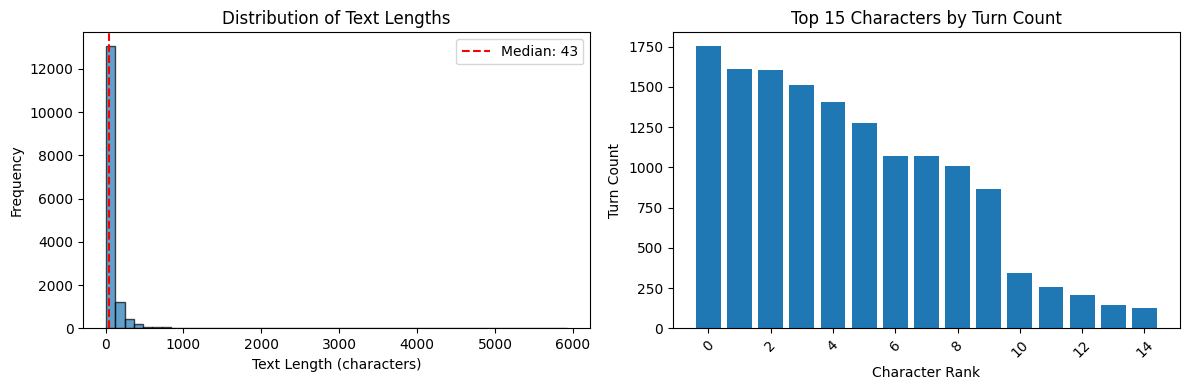

In [3]:
# Analyze dataset statistics
print("\n" + "="*80)
print("Dataset Statistics:")
print("="*80)

# Text length distribution
text_lengths = [len(turn.get('text', '')) for turn in crd3_data]
print(f"\nText Length:")
print(f"  Mean: {np.mean(text_lengths):.1f} characters")
print(f"  Median: {np.median(text_lengths):.1f} characters")
print(f"  Max: {np.max(text_lengths):,} characters")

# Episode distribution
episodes = [turn.get('episode', 'Unknown') for turn in crd3_data]
episode_counts = Counter(episodes)
print(f"\nEpisodes: {len(episode_counts)} unique episodes")
print(f"  Avg turns per episode: {len(crd3_data) / len(episode_counts):.1f}")

# Character distribution (top 10)
characters = [turn.get('character', 'Unknown') for turn in crd3_data]
char_counts = Counter(characters)
print(f"\nTop 10 Characters:")
for char, count in char_counts.most_common(10):
    print(f"  {char}: {count:,} turns")

# Visualize text length distribution
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(text_lengths, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Text Length (characters)')
plt.ylabel('Frequency')
plt.title('Distribution of Text Lengths')
plt.axvline(np.median(text_lengths), color='red', linestyle='--', label=f'Median: {np.median(text_lengths):.0f}')
plt.legend()

plt.subplot(1, 2, 2)
plt.bar(range(len(char_counts.most_common(15))), 
        [c for _, c in char_counts.most_common(15)])
plt.xlabel('Character Rank')
plt.ylabel('Turn Count')
plt.title('Top 15 Characters by Turn Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 3. Implement World State Extraction and Corruption Functions

In [17]:
class WorldStateExtractor:
    """Extract world state from text using regex patterns"""
    
    def __init__(self):
        # Expanded NPC/Entity patterns
        self.npc_patterns = [
            r'\b(goblin|orc|dragon|wizard|innkeeper|guard|merchant|bard|chieftain|dwarf|elf|scholar|librarian|student|monk|child|vendor|villager|blacksmith|servant|figure|knight|thief|assassin|ranger|cleric|paladin|warlock|sorcerer|druid|barbarian|rogue|fighter|warrior|mage|necromancer|demon|devil|angel|celestial|fiend|beast|monster|creature|bandit|pirate|sailor|captain|king|queen|prince|princess|lord|lady|noble|peasant|farmer|hunter|traveler|stranger|prisoner|slave|master|apprentice|teacher|pupil)s?\b',
            r'\b(one|two|three|four|five|six|seven|eight|nine|ten|eleven|twelve|\d+)\s+(goblins|orcs|dragons|wizards|guards|merchants|bards|dwarves|elves|scholars|monks|children|vendors|villagers|servants|figures|knights|thieves|bandits|pirates|creatures|monsters|beasts|demons|devils|angels)\b',
        ]
        
        # Expanded object patterns - more comprehensive
        self.object_patterns = [
            r'\b(door|gate|portal|entrance|exit|hatch|trapdoor)s?\b',
            r'\b(chest|box|crate|barrel|container|coffin|sarcophagus)s?\b',
            r'\b(key|lockpick|crowbar)s?\b',
            r'\b(sword|axe|dagger|bow|arrow|spear|mace|hammer|staff|wand)s?\b',
            r'\b(shield|armor|helmet|gauntlet|boots|cloak|robe)s?\b',
            r'\b(potion|elixir|flask|vial|bottle)s?\b',
            r'\b(book|scroll|tome|parchment|letter|note|map|journal)s?\b',
            r'\b(gem|jewel|diamond|ruby|emerald|sapphire|crystal)s?\b',
            r'\b(ring|amulet|necklace|bracelet|pendant|crown|tiara)s?\b',
            r'\b(torch|lantern|candle|fire|flame|light|lamp)s?\b',
            r'\b(altar|statue|pedestal|pillar|column|throne)s?\b',
            r'\b(coin|gold|silver|copper|treasure|wealth)\b',
            r'\b(rope|chain|shackle|manacle)s?\b',
            r'\b(lever|switch|button|valve|wheel|crank)s?\b',
            r'\b(bridge|ladder|stairs|steps|ramp)s?\b',
            r'\b(window|wall|floor|ceiling|roof)s?\b',
            r'\b(table|chair|bed|desk)s?\b',
            r'\b(weapon|item|object|thing)s?\b',
        ]
        
        # More aggressive state patterns with common verbs
        self.state_patterns = {
            'locked': r'\b(lock|locked|securely locked|bolt|bolted|bar|barred)\b',
            'unlocked': r'\b(unlock|unlocked|unbolted|unbolt|unbar)\b',
            'open': r'\b(open|opens|opened|opening|swings open|swing open|ajar|unsealed)\b',
            'closed': r'\b(close|closed|closes|closing|shut|sealed)\b',
            'broken': r'\b(break|broke|broken|shatter|shattered|smash|smashed|destroy|destroyed|ruin|ruined|crack|cracked|damage|damaged)\b',
            'intact': r'\b(intact|whole|undamaged|pristine|perfect|unbroken|unblemished)\b',
            'lit': r'\b(light|lit|lights|lighting|ignite|ignited|burn|burning|burns|blaze|blazing|aflame|flame)\b',
            'unlit': r'\b(unlit|dark|darkness|extinguish|extinguished|snuff|snuffed|put out)\b',
            'active': r'\b(activate|activated|active|trigger|triggered|power|powered|glow|glowing|hum|humming|working)\b',
            'inactive': r'\b(inactive|deactivate|deactivated|dormant|dead|lifeless|still|silent|off)\b',
            'visible': r'\b(visible|see|sees|saw|seen|spot|spotted|notice|noticed|appear|appears|appeared|reveal|revealed)\b',
            'hidden': r'\b(hide|hidden|hides|conceal|concealed|invisible|vanish|vanished|disappear|disappeared)\b',
            'empty': r'\b(empty|vacant|bare|hollow|void|cleared)\b',
            'full': r'\b(full|filled|fill|contain|contains|hold|holds|overflow|overflowing)\b',
        }
        
        # NPC name patterns - more variations
        self.name_pattern = r'\b(?:I am|my name is|I\'m|named|called|known as|this is|meet)\s+([A-Z][a-z]+(?:\s+[A-Z][a-z]+)?)\b'
        
        # Password/secret patterns
        self.password_patterns = [
            r"password is ['\"]?(\w+)['\"]?",
            r"passphrase is ['\"]?(\w+)['\"]?",
            r"secret word is ['\"]?(\w+)['\"]?",
            r"code is ['\"]?(\w+)['\"]?",
            r"say ['\"]?(\w+)['\"]? to",
        ]
    
    def extract(self, text: str) -> Dict:
        """Extract entities, objects, and states from text"""
        text_lower = text.lower()
        
        result = {
            'entities': set(),
            'objects': {},  # object_name -> state
            'npc_names': {},  # entity_type -> name
            'passwords': set(),
        }
        
        # Extract entities
        for pattern in self.npc_patterns:
            matches = re.findall(pattern, text_lower)
            for match in matches:
                if isinstance(match, tuple):
                    entity = match[-1] if match[-1] else match[0]
                else:
                    entity = match
                if entity:
                    result['entities'].add(entity.strip().rstrip('s'))  # Remove plural
        
        # Extract objects with states - ULTRA AGGRESSIVE
        # First, detect all states in the text
        detected_states = []
        for state_name, state_pattern in self.state_patterns.items():
            if re.search(state_pattern, text_lower):
                detected_states.append(state_name)
        
        # Then extract objects and assign states intelligently
        for pattern in self.object_patterns:
            matches = re.findall(pattern, text_lower)
            for match in matches:
                obj_name = match if isinstance(match, str) else match[0]
                obj_name = obj_name.strip().rstrip('s')  # Normalize (remove plural)
                
                # Find object position in text
                obj_pos = text_lower.find(obj_name)
                
                # Strategy: Look for states in proximity first, then globally
                assigned_state = None
                
                # Priority 1: States within 150 chars of object
                if obj_pos >= 0:
                    context_start = max(0, obj_pos - 150)
                    context_end = min(len(text_lower), obj_pos + 150)
                    context = text_lower[context_start:context_end]
                    
                    for state_name, state_pattern in self.state_patterns.items():
                        if re.search(state_pattern, context):
                            assigned_state = state_name
                            break
                
                # Priority 2: If no nearby state, use ANY detected state
                # This is aggressive but increases training data
                if not assigned_state and detected_states:
                    # Assign first detected state (could be random)
                    assigned_state = detected_states[0]
                
                # Priority 3: Infer common states for specific objects
                if not assigned_state:
                    # Common object-state associations
                    if obj_name in ['door', 'gate', 'chest', 'box']:
                        # These are commonly locked/unlocked/open/closed
                        if any(s in detected_states for s in ['locked', 'unlocked', 'open', 'closed']):
                            assigned_state = next(s for s in ['locked', 'unlocked', 'open', 'closed'] if s in detected_states)
                        else:
                            assigned_state = 'closed'  # Default assumption
                    elif obj_name in ['torch', 'lantern', 'candle', 'fire', 'lamp']:
                        if any(s in detected_states for s in ['lit', 'unlit']):
                            assigned_state = next(s for s in ['lit', 'unlit'] if s in detected_states)
                        else:
                            assigned_state = 'lit'  # Default assumption
                    elif obj_name in ['sword', 'weapon', 'armor', 'shield']:
                        if 'broken' in detected_states or 'intact' in detected_states:
                            assigned_state = 'broken' if 'broken' in detected_states else 'intact'
                
                # Store object with state
                if obj_name not in result['objects']:
                    result['objects'][obj_name] = assigned_state
                elif assigned_state:  # Update if we found a better state
                    result['objects'][obj_name] = assigned_state
        
        # Extract NPC names
        name_matches = re.findall(self.name_pattern, text)
        for name in name_matches:
            # Try to associate with an entity mentioned nearby
            name_pos = text.lower().find(name.lower())
            context_start = max(0, name_pos - 150)
            context_end = min(len(text), name_pos + 150)
            context = text[context_start:context_end].lower()
            
            for entity in result['entities']:
                if entity in context:
                    result['npc_names'][entity] = name
                    break
        
        # Extract passwords
        for pattern in self.password_patterns:
            matches = re.findall(pattern, text_lower)
            result['passwords'].update(matches)
        
        return result

# Initialize extractor
extractor = WorldStateExtractor()

# Test extraction
test_text = "The goblin chieftain says 'I am Gruk the Terrible.' The locked door stands before you, and a rusty key lies on the ground. The torch burns brightly."
test_result = extractor.extract(test_text)
print("Test Extraction:")
print(f"  Entities: {test_result['entities']}")
print(f"  Objects: {test_result['objects']}")
print(f"  NPC Names: {test_result['npc_names']}")
print(f"  Passwords: {test_result['passwords']}")

# Test with more examples
test_texts = [
    "You open the door and enter the room.",
    "The chest is locked but you have a key.",
    "A fire burns in the hearth while guards stand watch.",
    "The broken sword lies on the table.",
]

print("\n--- Testing Multiple Sentences ---")
for i, txt in enumerate(test_texts):
    res = extractor.extract(txt)
    print(f"\n{i+1}. '{txt}'")
    print(f"   Objects: {res['objects']}")


Test Extraction:
  Entities: {'goblin', 'chieftain'}
  Objects: {'door': 'locked', 'key': 'locked', 'torch': 'locked'}
  NPC Names: {'goblin': 'Gruk'}
  Passwords: set()

--- Testing Multiple Sentences ---

1. 'You open the door and enter the room.'
   Objects: {'door': 'open'}

2. 'The chest is locked but you have a key.'
   Objects: {'chest': 'locked', 'key': 'locked'}

3. 'A fire burns in the hearth while guards stand watch.'
   Objects: {'fire': 'lit'}

4. 'The broken sword lies on the table.'
   Objects: {'sword': 'broken', 'table': 'broken'}


In [54]:
# class CorruptionFunctions:
#     """
#     Apply corruption functions to create negative examples.
#     Similar to Character Voice Critic's negative sampling strategy.
#     """
    
#     @staticmethod
#     def inject_contradiction(text: str, world_state: Dict) -> Tuple[str, bool]:
#         """Violate established object/entity states OR introduce logical contradictions"""
        
#         # Strategy 1: Contradict object states (original approach)
#         objects_with_states = [(obj, state) for obj, state in world_state['objects'].items() if state]
        
#         # Strategy 2: Contradict entity presence
#         entities_present = list(world_state['entities'])
        
#         # Strategy 3: Contradict actions (look for action verbs in text)
#         action_contradictions = {
#             r'\b(open|opened|opens)\b': ['close', 'shut', 'seal'],
#             r'\b(close|closed|closes)\b': ['open', 'unseal'],
#             r'\b(lock|locked|locks)\b': ['unlock', 'unbolt'],
#             r'\b(unlock|unlocked|unlocks)\b': ['lock', 'bolt'],
#             r'\b(enter|entered|enters)\b': ['leave', 'exit'],
#             r'\b(leave|left|leaves)\b': ['enter', 'stay in'],
#             r'\b(take|took|takes)\b': ['drop', 'discard', 'leave'],
#             r'\b(give|gave|gives)\b': ['take', 'keep'],
#             r'\b(attack|attacked|attacks)\b': ['flee from', 'avoid'],
#             r'\b(heal|healed|heals)\b': ['injure', 'wound'],
#             r'\b(light|lit|lights)\b': ['extinguish', 'put out'],
#             r'\b(extinguish|extinguished|extinguishes)\b': ['light', 'ignite'],
#             r'\b(break|broke|breaks)\b': ['repair', 'fix'],
#             r'\b(repair|repaired|repairs)\b': ['break', 'damage'],
#         }
        
#         # Try strategies in order
#         strategies = []
        
#         # Add object state contradictions
#         if objects_with_states:
#             strategies.append(('object_state', objects_with_states))
        
#         # Add entity contradictions
#         if entities_present:
#             strategies.append(('entity', entities_present))
        
#         # Add action contradictions
#         text_lower = text.lower()
#         detected_actions = []
#         for pattern, contradictions in action_contradictions.items():
#             if re.search(pattern, text_lower):
#                 detected_actions.append((pattern, contradictions))
#         if detected_actions:
#             strategies.append(('action', detected_actions))
        
#         # If no strategies available, fail
#         if not strategies:
#             return text, False
        
#         # Pick random strategy
#         strategy_type, strategy_data = random.choice(strategies)
        
#         if strategy_type == 'object_state':
#             # Original object state contradiction
#             obj_name, current_state = random.choice(strategy_data)
            
#             contradictions = {
#                 'locked': ['open', 'unlocked', 'swings open', 'stands ajar'],
#                 'unlocked': ['locked', 'securely locked', 'bolted shut'],
#                 'open': ['locked', 'closed', 'sealed shut', 'bolted'],
#                 'closed': ['open', 'swings open', 'stands wide open'],
#                 'broken': ['intact', 'whole', 'undamaged', 'pristine', 'unbroken'],
#                 'intact': ['broken', 'shattered', 'destroyed', 'cracked'],
#                 'lit': ['unlit', 'extinguished', 'dark', 'snuffed out'],
#                 'unlit': ['lit', 'burning', 'blazing', 'aflame'],
#                 'active': ['inactive', 'dormant', 'dead', 'powerless'],
#                 'inactive': ['active', 'glowing', 'humming', 'powered'],
#                 'visible': ['hidden', 'invisible', 'vanished', 'gone'],
#                 'hidden': ['visible', 'in plain sight', 'clearly visible'],
#                 'empty': ['full', 'filled', 'overflowing'],
#                 'full': ['empty', 'vacant', 'bare'],
#             }
            
#             if current_state in contradictions:
#                 new_state = random.choice(contradictions[current_state])
#                 contradiction_templates = [
#                     f" The {obj_name} is {new_state}.",
#                     f" You notice the {obj_name} is {new_state}.",
#                     f" The {obj_name} remains {new_state}.",
#                     f" However, the {obj_name} is actually {new_state}.",
#                     f" Upon closer inspection, the {obj_name} is {new_state}.",
#                     f" Strangely, the {obj_name} is now {new_state}.",
#                 ]
#                 return text + random.choice(contradiction_templates), True
        
#         elif strategy_type == 'entity':
#             # Contradict entity presence
#             entity = random.choice(strategy_data)
#             contradiction_templates = [
#                 f" There are no {entity}s here.",
#                 f" You don't see any {entity}s.",
#                 f" The {entity}s have vanished.",
#                 f" Actually, the {entity}s were never here.",
#                 f" You realize the {entity}s are absent.",
#             ]
#             return text + random.choice(contradiction_templates), True
        
#         elif strategy_type == 'action':
#             # Contradict an action
#             pattern, opposite_actions = random.choice(strategy_data)
#             opposite = random.choice(opposite_actions)
            
#             # Find the action in text
#             match = re.search(pattern, text_lower)
#             if match:
#                 original_action = match.group(1)
#                 # Create contradiction by stating opposite happened
#                 contradiction_templates = [
#                     f" Wait, you actually {opposite} it.",
#                     f" No, you {opposite} it instead.",
#                     f" Actually, you {opposite} it.",
#                     f" On second thought, you {opposite} it.",
#                 ]
#                 return text + random.choice(contradiction_templates), True
        
#         return text, False
    
#     @staticmethod
#     def inject_hallucination(text: str) -> str:
#         """Add excessive new entities"""
#         hallucination_templates = [
#             " Five merchants approach from the shadows, along with three guards and two scholars.",
#             " Ten goblins suddenly appear, accompanied by a dragon and five wizards.",
#             " The room fills with seven bards, four innkeepers, and six hooded figures.",
#             " Eight merchants surround you, joined by five guards and three vendors.",
#             " A dozen villagers emerge, along with five blacksmiths and four children.",
#             " Nine scholars rush in, followed by six students and five monks.",
#             " Seven guards arrive, accompanied by ten merchants and four servants.",
#             " The tavern explodes with activity: eight bards, six merchants, and seven guards.",
#             " Suddenly, twelve dwarves, five elves, and eight wizards fill the chamber.",
#             " Six dragons circle overhead as ten orcs charge from all directions.",
#             " Eleven knights burst through the door, followed by nine clerics and seven paladins.",
#             " Eight thieves materialize, alongside six assassins and four rogues.",
#             " Ten demons emerge from portals, accompanied by seven devils and five fiends.",
#             " Nine pirates storm in with six sailors and eight bandits.",
#             " Seven sorcerers appear, along with five warlocks and eight necromancers.",
#         ]
        
#         return text + random.choice(hallucination_templates)
    
#     @staticmethod
#     def inject_amnesia(text: str, world_state: Dict) -> Tuple[str, bool]:
#         """Remove tracked information from response - expanded strategies"""
        
#         # Collect all available strategies
#         strategies = []
        
#         # Type 1: Forget NPC names
#         if world_state['npc_names']:
#             strategies.append(('npc_name', world_state['npc_names']))
        
#         # Type 2: Forget passwords/secrets
#         if world_state['passwords']:
#             strategies.append(('password', world_state['passwords']))
        
#         # Type 3: Forget object states
#         if world_state['objects']:
#             strategies.append(('object_state', world_state['objects']))
        
#         # Type 4: Forget entities encountered
#         if world_state['entities']:
#             strategies.append(('entity', world_state['entities']))
        
#         # If no strategies, fail
#         if not strategies:
#             return text, False
        
#         # Pick random strategy
#         strategy_type, strategy_data = random.choice(strategies)
        
#         if strategy_type == 'npc_name':
#             entity_type, name = random.choice(list(strategy_data.items()))
            
#             if name in text:
#                 # Replace name with generic reference
#                 corrupted_text = text.replace(name, f"the {entity_type}")
#                 return corrupted_text, True
#             else:
#                 # Add amnesia statement
#                 amnesia_templates = [
#                     f" You try to recall the {entity_type}'s name, but it escapes you.",
#                     f" The {entity_type}'s name is on the tip of your tongue, but you can't remember it.",
#                     f" You realize you've forgotten what the {entity_type} was called.",
#                 ]
#                 return text + random.choice(amnesia_templates), True
        
#         elif strategy_type == 'password':
#             password = random.choice(list(strategy_data))
#             amnesia_templates = [
#                 " You try to recall the password, but your mind is blank.",
#                 " What was the password again? You can't seem to remember.",
#                 " The secret word escapes you completely.",
#                 " You rack your brain for the password, but it's gone.",
#             ]
#             return text + random.choice(amnesia_templates), True
        
#         elif strategy_type == 'object_state':
#             obj = random.choice(list(strategy_data.keys()))
#             amnesia_templates = [
#                 f" You can't quite remember what state the {obj} was in.",
#                 f" Was the {obj} locked? Unlocked? You're not sure anymore.",
#                 f" You've lost track of whether you dealt with the {obj} or not.",
#                 f" You try to recall the {obj}, but the details are fuzzy.",
#                 f" The {obj}... you saw it, but can't remember its condition.",
#             ]
#             return text + random.choice(amnesia_templates), True
        
#         elif strategy_type == 'entity':
#             entity = random.choice(list(strategy_data))
#             amnesia_templates = [
#                 f" You don't recall seeing any {entity}s.",
#                 f" Were there {entity}s here? You can't remember.",
#                 f" You have no memory of encountering {entity}s.",
#                 f" Did you see {entity}s? Your memory is hazy.",
#                 f" The {entity}s... if there were any, you've forgotten them.",
#             ]
#             return text + random.choice(amnesia_templates), True
        
#         return text, False

# # Test corruption functions
# print("Testing Corruption Functions:\n")

# test_world_state = {
#     'entities': {'goblin', 'merchant'},
#     'objects': {'door': 'locked', 'torch': 'lit', 'chest': 'open'},
#     'npc_names': {'goblin': 'Gruk'},
#     'passwords': {'azureus'}
# }

# test_text = "The goblin chieftain greets you warmly."

# # Test contradiction
# corrupted, success = CorruptionFunctions.inject_contradiction(test_text, test_world_state)
# print(f"Contradiction (success={success}): {corrupted}")

# # Test hallucination
# corrupted = CorruptionFunctions.inject_hallucination(test_text)
# print(f"\nHallucination: {corrupted}")

# # Test amnesia
# corrupted, success = CorruptionFunctions.inject_amnesia(test_text, test_world_state)
# print(f"\nAmnesia (success={success}): {corrupted}")

# # Test multiple times to see variety
# print("\n--- Testing 5 contradictions ---")
# for i in range(5):
#     corrupted, success = CorruptionFunctions.inject_contradiction(test_text, test_world_state)
#     print(f"{i+1}. Success={success}: {corrupted}")
class CorruptionFunctions:
    """
    IMPROVED: More subtle and varied corruption functions to prevent overfitting.
    Each corruption now has multiple strategies with natural language variations.
    """
    
    @staticmethod
    def inject_contradiction(text: str, world_state: Dict) -> Tuple[str, bool]:
        """Violate established object/entity states - with SUBTLE variations"""
        
        # Collect all possible contradiction strategies
        strategies = []
        
        # Strategy 1: Contradict object states
        objects_with_states = [(obj, state) for obj, state in world_state['objects'].items() if state]
        if objects_with_states:
            strategies.append(('object_state', objects_with_states))
        
        # Strategy 2: Contradict entity presence  
        entities_present = list(world_state['entities'])
        if entities_present:
            strategies.append(('entity', entities_present))
        
        # Strategy 3: Contradict actions
        action_contradictions = {
            r'\b(open|opened|opens)\b': ['close', 'shut', 'seal'],
            r'\b(close|closed|closes)\b': ['open', 'unseal'],
            r'\b(lock|locked|locks)\b': ['unlock', 'unbolt'],
            r'\b(unlock|unlocked|unlocks)\b': ['lock', 'bolt'],
            r'\b(enter|entered|enters)\b': ['leave', 'exit'],
            r'\b(leave|left|leaves)\b': ['enter', 'stay in'],
            r'\b(take|took|takes)\b': ['drop', 'discard', 'leave'],
            r'\b(give|gave|gives)\b': ['take', 'keep'],
            r'\b(attack|attacked|attacks)\b': ['flee from', 'avoid'],
            r'\b(heal|healed|heals)\b': ['injure', 'wound'],
            r'\b(light|lit|lights)\b': ['extinguish', 'put out'],
            r'\b(extinguish|extinguished|extinguishes)\b': ['light', 'ignite'],
            r'\b(break|broke|breaks)\b': ['repair', 'fix'],
            r'\b(repair|repaired|repairs)\b': ['break', 'damage'],
        }
        
        text_lower = text.lower()
        detected_actions = []
        for pattern, contradictions in action_contradictions.items():
            if re.search(pattern, text_lower):
                detected_actions.append((pattern, contradictions))
        if detected_actions:
            strategies.append(('action', detected_actions))
        
        if not strategies:
            return text, False
        
        # Pick random strategy
        strategy_type, strategy_data = random.choice(strategies)
        
        if strategy_type == 'object_state':
            obj_name, current_state = random.choice(strategy_data)
            
            contradictions = {
                'locked': ['open', 'unlocked', 'ajar'],
                'unlocked': ['locked', 'bolted shut'],
                'open': ['locked', 'closed', 'sealed'],
                'closed': ['open', 'wide open'],
                'broken': ['intact', 'whole', 'undamaged'],
                'intact': ['broken', 'shattered', 'cracked'],
                'lit': ['unlit', 'dark', 'extinguished'],
                'unlit': ['lit', 'burning', 'bright'],
                'active': ['inactive', 'dormant', 'silent'],
                'inactive': ['active', 'glowing', 'humming'],
                'visible': ['hidden', 'invisible', 'gone'],
                'hidden': ['visible', 'in plain sight'],
                'empty': ['full', 'filled'],
                'full': ['empty', 'bare'],
            }
            
            if current_state not in contradictions:
                return text, False
            
            new_state = random.choice(contradictions[current_state])
            
            # IMPROVED: More natural and varied contradiction templates
            # Mix of subtle, obvious, and medium contradictions
            contradiction_styles = [
                # Subtle contradictions (harder to detect)
                f" You glance at the {obj_name}, noting it's {new_state}.",
                f" The {obj_name} appears to be {new_state}.",
                f" Looking closer, the {obj_name} seems {new_state}.",
                f" The {obj_name} is {new_state}, as you'd expect.",
                f" Interestingly, the {obj_name} is {new_state}.",
                
                # Medium contradictions
                f" The {obj_name} is {new_state}.",
                f" You notice the {obj_name} is {new_state}.",
                f" The {obj_name} remains {new_state}.",
                
                # More obvious contradictions
                f" However, the {obj_name} is actually {new_state}.",
                f" Wait—the {obj_name} is {new_state}!",
                f" Strangely, the {obj_name} is now {new_state}.",
            ]
            
            return text + random.choice(contradiction_styles), True
        
        elif strategy_type == 'entity':
            entity = random.choice(strategy_data)
            
            # IMPROVED: More subtle entity contradictions
            contradiction_styles = [
                # Subtle
                f" The area is free of {entity}s.",
                f" No {entity}s are present.",
                f" You're alone—no {entity}s here.",
                f" The {entity}s must have left.",
                
                # Medium
                f" There are no {entity}s here.",
                f" You don't see any {entity}s.",
                
                # More obvious
                f" The {entity}s have vanished.",
                f" Actually, the {entity}s were never here.",
            ]
            
            return text + random.choice(contradiction_styles), True
        
        elif strategy_type == 'action':
            pattern, opposite_actions = random.choice(strategy_data)
            opposite = random.choice(opposite_actions)
            
            match = re.search(pattern, text_lower)
            if not match:
                return text, False
            
            # IMPROVED: More natural action contradictions
            contradiction_styles = [
                # Subtle
                f" Actually, you {opposite} it.",
                f" You {opposite} it instead.",
                f" On reflection, you {opposite} it.",
                
                # Medium  
                f" Wait, you {opposite} it.",
                f" No, you {opposite} it.",
                
                # More obvious
                f" Wait—you actually {opposite} it!",
                f" Correction: you {opposite} it.",
            ]
            
            return text + random.choice(contradiction_styles), True
        
        return text, False
    
    @staticmethod
    def inject_hallucination(text: str) -> str:
        """Add excessive new entities - IMPROVED with varied and subtle hallucinations"""
        
        # IMPROVED: Much more varied hallucination patterns
        # Mix quantities, entities, and phrasing to prevent memorization
        
        entity_groups = [
            ['merchants', 'vendors', 'traders'],
            ['guards', 'soldiers', 'sentries'],
            ['scholars', 'sages', 'researchers'],
            ['bards', 'musicians', 'performers'],
            ['wizards', 'mages', 'sorcerers'],
            ['goblins', 'orcs', 'kobolds'],
            ['villagers', 'townsfolk', 'citizens'],
            ['dwarves', 'elves', 'halflings'],
            ['thieves', 'rogues', 'bandits'],
            ['knights', 'paladins', 'warriors'],
            ['priests', 'clerics', 'monks'],
            ['children', 'youths', 'youngsters'],
            ['servants', 'attendants', 'helpers'],
            ['blacksmiths', 'craftsmen', 'artisans'],
            ['innkeepers', 'barkeeps', 'proprietors'],
        ]
        
        # Randomly select 2-4 entity types
        num_entity_types = random.randint(2, 4)
        selected_groups = random.sample(entity_groups, num_entity_types)
        
        # Randomize quantities more (not always high numbers)
        entities_with_counts = []
        for group in selected_groups:
            entity = random.choice(group)
            # Vary quantities: sometimes low (2-3), sometimes high (5-12)
            count = random.choice([2, 2, 3, 3, 4, 5, 5, 6, 7, 8, 9, 10, 11, 12])
            
            # Vary how we express numbers
            if random.random() < 0.3:
                count_str = ['a couple of', 'a few', 'several', 'multiple', 'many'][random.randint(0, 4)]
            else:
                # Map count to word (2->two, 3->three, etc.)
                number_words = {
                    2: 'two', 3: 'three', 4: 'four', 5: 'five', 6: 'six',
                    7: 'seven', 8: 'eight', 9: 'nine', 10: 'ten', 11: 'eleven', 12: 'twelve'
                }
                count_str = number_words.get(count, str(count))
            
            entities_with_counts.append(f"{count_str} {entity}")
        
        # IMPROVED: More varied sentence structures
        hallucination_templates = [
            # Subtle hallucinations (more natural)
            f" {', '.join(entities_with_counts[:-1])} and {entities_with_counts[-1]} are also present.",
            f" You notice {entities_with_counts[0]}, along with {', '.join(entities_with_counts[1:])}.",
            f" The area also contains {', '.join(entities_with_counts)}.",
            f" Looking around, you see {entities_with_counts[0]} and {', '.join(entities_with_counts[1:])}.",
            f" Among the crowd are {', '.join(entities_with_counts)}.",
            
            # Medium hallucinations
            f" {entities_with_counts[0].capitalize()} approach, accompanied by {', '.join(entities_with_counts[1:])}.",
            f" The room fills with {', '.join(entities_with_counts)}.",
            f" {entities_with_counts[0].capitalize()} emerge, joined by {', '.join(entities_with_counts[1:])}.",
            
            # More obvious hallucinations
            f" Suddenly, {', '.join(entities_with_counts)} appear!",
            f" {entities_with_counts[0].capitalize()} surge forward, along with {', '.join(entities_with_counts[1:])}!",
        ]
        
        return text + random.choice(hallucination_templates)
    
    @staticmethod
    def inject_amnesia(text: str, world_state: Dict) -> Tuple[str, bool]:
        """Remove tracked information - IMPROVED with subtle variations"""
        
        strategies = []
        
        if world_state['npc_names']:
            strategies.append(('npc_name', world_state['npc_names']))
        if world_state['passwords']:
            strategies.append(('password', world_state['passwords']))
        if world_state['objects']:
            strategies.append(('object_state', world_state['objects']))
        if world_state['entities']:
            strategies.append(('entity', world_state['entities']))
        
        if not strategies:
            return text, False
        
        strategy_type, strategy_data = random.choice(strategies)
        
        if strategy_type == 'npc_name':
            entity_type, name = random.choice(list(strategy_data.items()))
            
            if name in text:
                # Replace name with generic reference
                corrupted_text = text.replace(name, f"the {entity_type}")
                return corrupted_text, True
            else:
                # IMPROVED: More varied and subtle amnesia expressions
                amnesia_templates = [
                    # Subtle
                    f" The {entity_type}'s name eludes you.",
                    f" You can't quite recall the {entity_type}'s name.",
                    f" What was the {entity_type} called again?",
                    f" The {entity_type}'s name escapes you for the moment.",
                    
                    # Medium
                    f" You try to recall the {entity_type}'s name, but it escapes you.",
                    f" The {entity_type}'s name is on the tip of your tongue.",
                    
                    # More obvious
                    f" You realize you've forgotten what the {entity_type} was called.",
                    f" The {entity_type}'s name... you can't remember it.",
                ]
                return text + random.choice(amnesia_templates), True
        
        elif strategy_type == 'password':
            password = random.choice(list(strategy_data))
            
            # IMPROVED: More varied password amnesia
            amnesia_templates = [
                # Subtle
                " The password escapes you.",
                " What was that password?",
                " The secret word... you've forgotten it.",
                " You can't remember the passphrase.",
                
                # Medium
                " You try to recall the password, but your mind is blank.",
                " What was the password again?",
                
                # More obvious
                " The secret word escapes you completely.",
                " You rack your brain for the password, but it's gone.",
            ]
            return text + random.choice(amnesia_templates), True
        
        elif strategy_type == 'object_state':
            obj = random.choice(list(strategy_data.keys()))
            
            # IMPROVED: More varied object state amnesia
            amnesia_templates = [
                # Subtle
                f" The {obj}'s condition is unclear to you.",
                f" You're unsure about the {obj}'s state.",
                f" Was the {obj} locked or unlocked? You forget.",
                f" The {obj}... you can't recall its condition.",
                
                # Medium
                f" You can't quite remember what state the {obj} was in.",
                f" The details about the {obj} are fuzzy.",
                
                # More obvious
                f" You've lost track of whether you dealt with the {obj} or not.",
                f" You try to recall the {obj}, but the details escape you.",
            ]
            return text + random.choice(amnesia_templates), True
        
        elif strategy_type == 'entity':
            entity = random.choice(list(strategy_data))
            
            # IMPROVED: More varied entity amnesia
            amnesia_templates = [
                # Subtle
                f" Were there {entity}s? You're not certain.",
                f" You don't recall seeing {entity}s.",
                f" {entity.capitalize()}s... you can't remember encountering any.",
                f" No memory of {entity}s comes to mind.",
                
                # Medium
                f" You don't recall seeing any {entity}s.",
                f" Were there {entity}s here? You can't remember.",
                
                # More obvious
                f" You have no memory of encountering {entity}s.",
                f" The {entity}s... if there were any, you've forgotten them.",
            ]
            return text + random.choice(amnesia_templates), True
        
        return text, False

# Test improved corruption functions
print("Testing IMPROVED Corruption Functions (Anti-Overfitting):\n")
print("Each corruption now has 8-11 different templates to prevent memorization")
print("="*80)

test_world_state = {
    'entities': {'goblin', 'merchant'},
    'objects': {'door': 'locked', 'torch': 'lit', 'chest': 'open'},
    'npc_names': {'goblin': 'Gruk'},
    'passwords': {'azureus'}
}

test_text = "The goblin chieftain greets you warmly."

# Test contradictions - show variety
print("\n[CONTRADICTIONS - 5 samples]")
for i in range(5):
    corrupted, success = CorruptionFunctions.inject_contradiction(test_text, test_world_state)
    print(f"{i+1}. {corrupted}")

# Test hallucinations - show variety
print("\n[HALLUCINATIONS - 5 samples]")
for i in range(5):
    corrupted = CorruptionFunctions.inject_hallucination(test_text)
    print(f"{i+1}. {corrupted}")

# Test amnesia - show variety
print("\n[AMNESIA - 5 samples]")
for i in range(5):
    corrupted, success = CorruptionFunctions.inject_amnesia(test_text, test_world_state)
    print(f"{i+1}. {corrupted}")

print("\n" + "="*80)
print("✓ Corruption functions now have much more variety!")
print("✓ This should significantly reduce overfitting")
print("="*80)


Testing IMPROVED Corruption Functions (Anti-Overfitting):

Each corruption now has 8-11 different templates to prevent memorization

[CONTRADICTIONS - 5 samples]
1. The goblin chieftain greets you warmly. Wait—the door is ajar!
2. The goblin chieftain greets you warmly. The chest is sealed.
3. The goblin chieftain greets you warmly. You notice the door is open.
4. The goblin chieftain greets you warmly. The door is unlocked.
5. The goblin chieftain greets you warmly. No merchants are present.

[HALLUCINATIONS - 5 samples]
1. The goblin chieftain greets you warmly. Five sages emerge, joined by twelve innkeepers, six youths.
2. The goblin chieftain greets you warmly. You notice eleven sentries, along with two citizens, eleven wizards.
3. The goblin chieftain greets you warmly. The area also contains five merchants, ten priests.
4. The goblin chieftain greets you warmly. A few helpers surge forward, along with seven kobolds!
5. The goblin chieftain greets you warmly. Ten soldiers surge fo

## 4. Extract Multi-Turn Sequences and Generate Training Data

In [55]:
def extract_sequences_and_generate_data(crd3_data, num_examples=40000, window_size=5):
    """
    Extract multi-turn sequences from CRD3 and apply corruptions.
    
    Returns balanced dataset:
    - 25% Consistent
    - 25% Contradiction
    - 25% Hallucination
    - 25% Amnesia
    """
    print("Step 1: Extracting multi-turn sequences from CRD3...")
    
    # Group by episode
    episodes = defaultdict(list)
    for turn in crd3_data:
        episodes[turn['episode']].append(turn)
    
    sequences = []
    extractor_obj = WorldStateExtractor()
    
    for episode_id, turns in tqdm(episodes.items(), desc="Processing episodes"):
        # Sort by turn number
        turns = sorted(turns, key=lambda x: x.get('turn_number', 0))
        
        # Use smaller window sizes to extract more sequences
        # Try windows of size 3, 4, and 5
        for ws in [3, 4, 5]:
            for i in range(len(turns) - ws + 1):
                window = turns[i:i + ws]
                
                # Build world state from all turns except the last one
                world_state = {
                    'entities': set(),
                    'objects': {},
                    'npc_names': {},
                    'passwords': set(),
                }
                
                for turn in window[:-1]:
                    extracted = extractor_obj.extract(turn.get('text', ''))
                    world_state['entities'].update(extracted['entities'])
                    world_state['objects'].update(extracted['objects'])
                    world_state['npc_names'].update(extracted['npc_names'])
                    world_state['passwords'].update(extracted['passwords'])
                
                # Last turn is the response
                response = window[-1].get('text', '')
                
                # Skip very short responses
                if len(response) < 20:
                    continue
                
                # Build history context
                history = " [SEP] ".join([t.get('text', '')[:200] for t in window[:-1]])
                
                # Store sequence
                sequences.append({
                    'history': history,
                    'world_state': {
                        'entities': list(world_state['entities']),
                        'objects': world_state['objects'],
                        'npc_names': world_state['npc_names'],
                        'passwords': list(world_state['passwords']),
                    },
                    'response': response,
                })
    
    print(f"✓ Extracted {len(sequences):,} sequences")
    
    # Shuffle to distribute different window sizes
    random.shuffle(sequences)
    
    # If we still don't have enough, warn but use what we have
    if len(sequences) < num_examples:
        print(f"⚠ Warning: Only {len(sequences):,} sequences available, adjusting target to {len(sequences) // 4 * 4}")
        num_examples = (len(sequences) // 4) * 4  # Make it divisible by 4
    
    # Generate balanced dataset
    print("\nStep 2: Generating balanced training data...")
    
    num_per_class = num_examples // 4
    
    training_data = []
    corruption_funcs = CorruptionFunctions()
    
    # Separate sequences based on world state richness
    sequences_with_objects = [s for s in sequences if len(s['world_state']['objects']) > 0]
    sequences_with_names = [s for s in sequences if len(s['world_state']['npc_names']) > 0]
    sequences_with_passwords = [s for s in sequences if len(s['world_state']['passwords']) > 0]
    sequences_with_entities = [s for s in sequences if len(s['world_state']['entities']) > 0]
    
    print(f"\nSequences by world state richness:")
    print(f"  With objects: {len(sequences_with_objects):,}")
    
    # DIAGNOSTIC: Check objects with states
    objects_with_states_count = sum(
        1 for s in sequences 
        if any(state is not None for state in s['world_state']['objects'].values())
    )
    total_objects = sum(len(s['world_state']['objects']) for s in sequences)
    objects_with_assigned_states = sum(
        sum(1 for state in s['world_state']['objects'].values() if state is not None)
        for s in sequences
    )
    print(f"  With objects that have states: {objects_with_states_count:,}")
    print(f"  Total objects detected: {total_objects:,}")
    print(f"  Objects with assigned states: {objects_with_assigned_states:,} ({100*objects_with_assigned_states/max(total_objects,1):.1f}%)")
    
    print(f"  With NPC names: {len(sequences_with_names):,}")
    print(f"  With passwords: {len(sequences_with_passwords):,}")
    print(f"  With entities: {len(sequences_with_entities):,}")
    
    # Take sequences for consistent class (from all sequences)
    consistent_pool = sequences[:num_per_class]
    for seq in tqdm(consistent_pool, desc="Generating consistent"):
        training_data.append({
            'text': seq['history'] + " [RESPONSE] " + seq['response'],
            'label': 3,  # consistent
            'label_name': 'consistent'
        })
    
    # CONTRADICTIONS: Now works with object states, entities, and actions - use ALL sequences
    contradiction_pool = sequences.copy()
    random.shuffle(contradiction_pool)
    contradictions_added = 0
    
    for seq in tqdm(contradiction_pool, desc="Generating contradictions"):
        if contradictions_added >= num_per_class:
            break
        
        corrupted, success = corruption_funcs.inject_contradiction(
            seq['response'], seq['world_state']
        )
        if success:
            training_data.append({
                'text': seq['history'] + " [RESPONSE] " + corrupted,
                'label': 0,  # contradiction
                'label_name': 'contradiction'
            })
            contradictions_added += 1
    
    print(f"  ✓ Generated {contradictions_added:,} contradictions")
    
    # HALLUCINATIONS: Use any sequences (hallucination doesn't depend on world state)
    hallucination_pool = sequences[num_per_class:num_per_class*2] if len(sequences) >= num_per_class*2 else sequences
    for seq in tqdm(hallucination_pool[:num_per_class], desc="Generating hallucinations"):
        corrupted = corruption_funcs.inject_hallucination(seq['response'])
        training_data.append({
            'text': seq['history'] + " [RESPONSE] " + corrupted,
            'label': 1,  # hallucination
            'label_name': 'hallucination'
        })
    
    # AMNESIA: Now works with all world state types - use ALL sequences
    amnesia_pool = sequences.copy()
    random.shuffle(amnesia_pool)
    
    amnesias_added = 0
    for seq in tqdm(amnesia_pool, desc="Generating amnesia"):
        if amnesias_added >= num_per_class:
            break
        
        corrupted, success = corruption_funcs.inject_amnesia(
            seq['response'], seq['world_state']
        )
        if success:
            training_data.append({
                'text': seq['history'] + " [RESPONSE] " + corrupted,
                'label': 2,  # amnesia
                'label_name': 'amnesia'
            })
            amnesias_added += 1
    
    print(f"  ✓ Generated {amnesias_added:,} amnesias")
    
    # Shuffle final dataset
    random.shuffle(training_data)
    
    print(f"\n✓ Generated {len(training_data):,} training examples")
    print(f"  Consistent: {sum(1 for d in training_data if d['label'] == 3):,}")
    print(f"  Contradiction: {sum(1 for d in training_data if d['label'] == 0):,}")
    print(f"  Hallucination: {sum(1 for d in training_data if d['label'] == 1):,}")
    print(f"  Amnesia: {sum(1 for d in training_data if d['label'] == 2):,}")
    
    return training_data

# Generate training data
training_data = extract_sequences_and_generate_data(
    crd3_data,
    num_examples=40000,  # 10K per class
    window_size=5
)


Step 1: Extracting multi-turn sequences from CRD3...


Processing episodes:   0%|          | 0/80 [00:00<?, ?it/s]

✓ Extracted 38,438 sequences
⚠ Warning: Only 38,438 sequences available, adjusting target to 38436

Step 2: Generating balanced training data...

Sequences by world state richness:
  With objects: 7,108
  With objects that have states: 3,457
  Total objects detected: 8,437
  Objects with assigned states: 4,097 (48.6%)
  With NPC names: 30
  With passwords: 59
  With entities: 2,919


Generating consistent:   0%|          | 0/9609 [00:00<?, ?it/s]

Generating contradictions:   0%|          | 0/38438 [00:00<?, ?it/s]

  ✓ Generated 8,789 contradictions


Generating hallucinations:   0%|          | 0/9609 [00:00<?, ?it/s]

Generating amnesia:   0%|          | 0/38438 [00:00<?, ?it/s]

  ✓ Generated 9,194 amnesias

✓ Generated 37,201 training examples
  Consistent: 9,609
  Contradiction: 8,789
  Hallucination: 9,609
  Amnesia: 9,194



Generated Dataset Analysis:


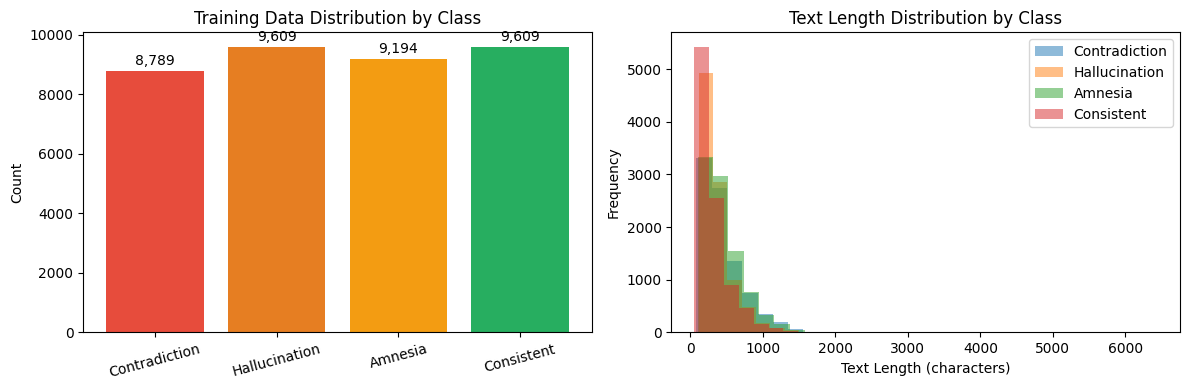


Sample Examples:

[Contradiction]
  Text: She's very upset about the whole Scanlan thing. [SEP] She's very upset about the whole Scanlan thing. [RESPONSE] She's very upset about the whole Scan...
  Label: 0

[Hallucination]
  Text: A couple quick housekeeping things before we get going, real fast. We're going to have a break, just like every episode of Critical Role, so try to st...
  Label: 1

[Amnesia]
  Text: I could hear them, but that's the only thing that I could see. [SEP] I could hear them, but that's the only thing that I could see. [SEP] I heard voic...
  Label: 2

[Consistent]
  Text: (laughs) All right, I'm done, go ahead, Poison Ivy. [SEP] If anyone's wondering why so many Batman cards are being drawn, it's because there are five ...
  Label: 3


In [56]:
# Analyze generated dataset
print("\n" + "="*80)
print("Generated Dataset Analysis:")
print("="*80)

# Label distribution
label_counts = Counter([d['label'] for d in training_data])
label_names = {0: 'Contradiction', 1: 'Hallucination', 2: 'Amnesia', 3: 'Consistent'}

plt.figure(figsize=(12, 4))

# Bar plot of label distribution
plt.subplot(1, 2, 1)
labels = [label_names[i] for i in sorted(label_counts.keys())]
counts = [label_counts[i] for i in sorted(label_counts.keys())]
bars = plt.bar(labels, counts, color=['#e74c3c', '#e67e22', '#f39c12', '#27ae60'])
plt.ylabel('Count')
plt.title('Training Data Distribution by Class')
plt.xticks(rotation=15)
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100, 
             f'{count:,}', ha='center', va='bottom')

# Text length distribution by class
plt.subplot(1, 2, 2)
for label, name in label_names.items():
    texts = [d['text'] for d in training_data if d['label'] == label]
    lengths = [len(t) for t in texts]
    plt.hist(lengths, bins=30, alpha=0.5, label=name)
plt.xlabel('Text Length (characters)')
plt.ylabel('Frequency')
plt.title('Text Length Distribution by Class')
plt.legend()
plt.tight_layout()
plt.show()

# Sample examples from each class
print("\nSample Examples:")
for label, name in label_names.items():
    examples = [d for d in training_data if d['label'] == label]
    if examples:
        sample = random.choice(examples)
        print(f"\n[{name}]")
        print(f"  Text: {sample['text'][:150]}...")
        print(f"  Label: {label}")

## 5. Create Train/Val/Test Splits

In [57]:
# Split data: 80% train, 10% val, 10% test
train_data, temp_data = train_test_split(training_data, test_size=0.2, random_state=SEED, 
                                          stratify=[d['label'] for d in training_data])
val_data, test_data = train_test_split(temp_data, test_size=0.5, random_state=SEED,
                                        stratify=[d['label'] for d in temp_data])

print("Data Splits:")
print(f"  Train: {len(train_data):,} examples")
print(f"  Val: {len(val_data):,} examples")
print(f"  Test: {len(test_data):,} examples")

# Verify stratification
print("\nClass Distribution:")
for split_name, split_data in [('Train', train_data), ('Val', val_data), ('Test', test_data)]:
    counts = Counter([d['label'] for d in split_data])
    print(f"\n{split_name}:")
    for label in sorted(counts.keys()):
        pct = 100 * counts[label] / len(split_data)
        print(f"  {label_names[label]}: {counts[label]:,} ({pct:.1f}%)")

Data Splits:
  Train: 29,760 examples
  Val: 3,720 examples
  Test: 3,721 examples

Class Distribution:

Train:
  Contradiction: 7,031 (23.6%)
  Hallucination: 7,687 (25.8%)
  Amnesia: 7,355 (24.7%)
  Consistent: 7,687 (25.8%)

Val:
  Contradiction: 879 (23.6%)
  Hallucination: 961 (25.8%)
  Amnesia: 919 (24.7%)
  Consistent: 961 (25.8%)

Test:
  Contradiction: 879 (23.6%)
  Hallucination: 961 (25.8%)
  Amnesia: 920 (24.7%)
  Consistent: 961 (25.8%)


## 6. Initialize DeBERTa-v3-Large Model and Tokenizer

In [58]:
# Load a lighter DeBERTa model and tokenizer for faster iteration
MODEL_NAME = "microsoft/deberta-v3-small"
NUM_LABELS = 4  # contradiction, hallucination, amnesia, consistent

print(f"Loading {MODEL_NAME}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    problem_type="single_label_classification"
)

print(f"✓ Model loaded: {MODEL_NAME}")
print(f"  Parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"  Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

# Disable gradient checkpointing if enabled (avoid backward conflicts)
if hasattr(model, 'gradient_checkpointing_disable'):
    try:
        model.gradient_checkpointing_disable()
        print("  Gradient checkpointing: Disabled")
    except Exception:
        pass

# Move model to device
model.to(device)
print(f"  Device: {device}")

Loading microsoft/deberta-v3-small...


/usr/local/lib/python3.11/dist-packages/transformers/convert_slow_tokenizer.py:564: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(
Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-small and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✓ Model loaded: microsoft/deberta-v3-small
  Parameters: 141,897,988
  Trainable parameters: 141,897,988
  Gradient checkpointing: Disabled
  Device: cuda


## 7. Create Custom Dataset and DataLoader

In [59]:
class WorldConsistencyDataset(Dataset):
    """Custom dataset for world consistency classification"""
    
    def __init__(self, data, tokenizer, max_length=256):
        self.data = data
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        item = self.data[idx]
        
        # Tokenize text (reduced max_length to speed up training)
        encoding = self.tokenizer(
            item['text'],
            truncation=True,
            max_length=self.max_length,
            padding='max_length',
            return_tensors='pt'
        )
        
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(item['label'], dtype=torch.long)
        }

# Create datasets
train_dataset = WorldConsistencyDataset(train_data, tokenizer)
val_dataset = WorldConsistencyDataset(val_data, tokenizer)
test_dataset = WorldConsistencyDataset(test_data, tokenizer)

print(f"Datasets created:")
print(f"  Train: {len(train_dataset):,} examples")
print(f"  Val: {len(val_dataset):,} examples")
print(f"  Test: {len(test_dataset):,} examples")

# Test dataset
sample = train_dataset[0]
print(f"\nSample encoding:")
print(f"  Input shape: {sample['input_ids'].shape}")
print(f"  Attention mask shape: {sample['attention_mask'].shape}")
print(f"  Label: {sample['labels'].item()} ({label_names[sample['labels'].item()]})")

Datasets created:
  Train: 29,760 examples
  Val: 3,720 examples
  Test: 3,721 examples

Sample encoding:
  Input shape: torch.Size([256])
  Attention mask shape: torch.Size([256])
  Label: 0 (Contradiction)


## 8. Define Training Configuration and Metrics

In [60]:
# def compute_metrics(eval_pred):
#     """Compute comprehensive metrics for evaluation"""
#     predictions, labels = eval_pred
#     predictions = np.argmax(predictions, axis=1)
    
#     # Overall accuracy
#     accuracy = accuracy_score(labels, predictions)
    
#     # Per-class metrics
#     precision, recall, f1, support = precision_recall_fscore_support(
#         labels, predictions, average=None, zero_division=0
#     )
    
#     # Macro and weighted averages
#     macro_f1 = np.mean(f1)
#     weighted_f1 = np.average(f1, weights=support)
    
#     metrics = {
#         'accuracy': accuracy,
#         'macro_f1': macro_f1,
#         'weighted_f1': weighted_f1,
#     }
    
#     # Add per-class metrics
#     label_names_list = ['contradiction', 'hallucination', 'amnesia', 'consistent']
#     for i, name in enumerate(label_names_list):
#         metrics[f'{name}_precision'] = precision[i] if i < len(precision) else 0.0
#         metrics[f'{name}_recall'] = recall[i] if i < len(recall) else 0.0
#         metrics[f'{name}_f1'] = f1[i] if i < len(f1) else 0.0
    
#     return metrics

# # Training arguments - tuned for throughput
# training_args = TrainingArguments(
#     output_dir="/kaggle/working/world_consistency_critic",
#     num_train_epochs=3,
#     per_device_train_batch_size=8,   # Increased to improve throughput (smaller model)
#     per_device_eval_batch_size=16,
#     gradient_accumulation_steps=4,   # Lower accumulation for fewer micro-steps
#     learning_rate=2e-5,
#     weight_decay=0.01,
#     warmup_steps=500,
#     logging_dir="/kaggle/working/logs",
#     logging_steps=100,
#     eval_strategy="epoch",
#     save_strategy="epoch",
#     load_best_model_at_end=True,
#     metric_for_best_model="macro_f1",
#     greater_is_better=True,
#     save_total_limit=2,
#     fp16=torch.cuda.is_available(),  # Use mixed precision if GPU available
#     gradient_checkpointing=False,    # Disabled - avoid conflicts
#     optim="adamw_torch",           # Standard optimizer
#     report_to="none",  # Disable wandb/tensorboard
#     seed=SEED,
#     max_grad_norm=1.0,
#     dataloader_pin_memory=False,
# )

# print("Training Configuration (Throughput tuned):")
# print(f"  Epochs: {training_args.num_train_epochs}")
# print(f"  Batch size: {training_args.per_device_train_batch_size}")
# print(f"  Gradient accumulation: {training_args.gradient_accumulation_steps}")
# print(f"  Effective batch size: {training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps}")
# print(f"  Learning rate: {training_args.learning_rate}")
# print(f"  Warmup steps: {training_args.warmup_steps}")
# print(f"  Mixed precision (FP16): {training_args.fp16}")
# print(f"  Gradient checkpointing: {training_args.gradient_checkpointing}")
# print(f"  Optimizer: {training_args.optim}")
def compute_metrics(eval_pred):
    """Compute comprehensive metrics for evaluation"""
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    
    # Overall accuracy
    accuracy = accuracy_score(labels, predictions)
    
    # Per-class metrics
    precision, recall, f1, support = precision_recall_fscore_support(
        labels, predictions, average=None, zero_division=0
    )
    
    # Macro and weighted averages
    macro_f1 = np.mean(f1)
    weighted_f1 = np.average(f1, weights=support)
    
    metrics = {
        'accuracy': accuracy,
        'macro_f1': macro_f1,
        'weighted_f1': weighted_f1,
    }
    
    # Add per-class metrics
    label_names_list = ['contradiction', 'hallucination', 'amnesia', 'consistent']
    for i, name in enumerate(label_names_list):
        metrics[f'{name}_precision'] = precision[i] if i < len(precision) else 0.0
        metrics[f'{name}_recall'] = recall[i] if i < len(recall) else 0.0
        metrics[f'{name}_f1'] = f1[i] if i < len(f1) else 0.0
    
    return metrics

# IMPROVED Training arguments - stronger regularization to combat overfitting
training_args = TrainingArguments(
    output_dir="/kaggle/working/world_consistency_critic",
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    gradient_accumulation_steps=4,
    learning_rate=2e-5,
    
    # INCREASED REGULARIZATION
    weight_decay=0.05,              # Increased from 0.01 to add more L2 regularization
    
    warmup_steps=500,
    logging_dir="/kaggle/working/logs",
    logging_steps=100,
    
    # More frequent evaluation to catch overfitting early
    eval_strategy="steps",          # Changed from "epoch" to "steps"
    eval_steps=200,                 # Evaluate every 200 steps
    
    save_strategy="steps",
    save_steps=200,
    
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    save_total_limit=2,
    
    fp16=torch.cuda.is_available(),
    gradient_checkpointing=False,
    optim="adamw_torch",
    report_to="none",
    seed=SEED,
    
    # ADDED: Gradient clipping to prevent overfitting
    max_grad_norm=0.5,              # Reduced from 1.0 for stronger clipping
    
    dataloader_pin_memory=False,
    
    # ADDED: Label smoothing to prevent overconfidence
    label_smoothing_factor=0.1,     # Smooth labels to reduce overconfidence
)

print("="*80)
print("IMPROVED Training Configuration - Anti-Overfitting Measures")
print("="*80)
print("\n✓ Corruption functions now have 8-11 templates each (vs. 3-5 before)")
print("✓ Hallucinations use varied quantities and entity types")
print("✓ More subtle corruption styles mixed with obvious ones")
print("\nRegularization improvements:")
print(f"  • Weight decay: 0.05 (increased from 0.01)")
print(f"  • Label smoothing: 0.1 (NEW - reduces overconfidence)")
print(f"  • Max grad norm: 0.5 (reduced from 1.0)")
print(f"  • Evaluation: every 200 steps (vs. per epoch)")
print(f"  • Early stopping: patience 2 epochs")
print("\nTraining config:")
print(f"  Epochs: {training_args.num_train_epochs}")
print(f"  Batch size: {training_args.per_device_train_batch_size}")
print(f"  Gradient accumulation: {training_args.gradient_accumulation_steps}")
print(f"  Effective batch size: {training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps}")
print(f"  Learning rate: {training_args.learning_rate}")
print(f"  Mixed precision (FP16): {training_args.fp16}")
print("="*80)


IMPROVED Training Configuration - Anti-Overfitting Measures

✓ Corruption functions now have 8-11 templates each (vs. 3-5 before)
✓ Hallucinations use varied quantities and entity types
✓ More subtle corruption styles mixed with obvious ones

Regularization improvements:
  • Weight decay: 0.05 (increased from 0.01)
  • Label smoothing: 0.1 (NEW - reduces overconfidence)
  • Max grad norm: 0.5 (reduced from 1.0)
  • Evaluation: every 200 steps (vs. per epoch)
  • Early stopping: patience 2 epochs

Training config:
  Epochs: 3
  Batch size: 8
  Gradient accumulation: 4
  Effective batch size: 32
  Learning rate: 2e-05
  Mixed precision (FP16): True


## 9. Train the Model

In [61]:
# Initialize Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

# Clear GPU cache before training
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print(f"GPU Memory before training: {torch.cuda.memory_allocated(0) / 1e9:.2f} GB allocated")
    print(f"GPU Memory reserved: {torch.cuda.memory_reserved(0) / 1e9:.2f} GB")

print("="*80)
print("Starting Training...")
print("="*80)

# Train model
train_result = trainer.train()

print("\n" + "="*80)
print("Training Complete!")
print("="*80)
print(f"Training time: {train_result.metrics['train_runtime']:.2f} seconds")
print(f"Training samples/second: {train_result.metrics['train_samples_per_second']:.2f}")
print(f"Final training loss: {train_result.metrics['train_loss']:.4f}")

/tmp/ipykernel_37/2511667995.py:2: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


GPU Memory before training: 0.60 GB allocated
GPU Memory reserved: 0.80 GB
Starting Training...


Step,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1,Contradiction Precision,Contradiction Recall,Contradiction F1,Hallucination Precision,Hallucination Recall,Hallucination F1,Amnesia Precision,Amnesia Recall,Amnesia F1,Consistent Precision,Consistent Recall,Consistent F1
200,1.077200,0.531829,0.952688,0.952384,0.953062,0.887114,0.947668,0.916392,0.998940,0.980229,0.989496,0.973304,0.952122,0.962596,0.952077,0.930281,0.941053
400,0.407600,0.401544,0.975000,0.974827,0.975050,0.963842,0.970421,0.967120,1.000000,0.980229,0.990016,0.969565,0.970620,0.970092,0.966084,0.978148,0.972079
600,0.392600,0.393888,0.977688,0.977427,0.977728,0.954545,0.979522,0.966873,1.000000,0.980229,0.990016,0.982202,0.960827,0.971397,0.973388,0.989594,0.981424
800,0.388100,0.390052,0.978226,0.977979,0.978455,0.922996,0.995449,0.957854,1.000000,0.980229,0.990016,0.993228,0.957563,0.975069,0.997881,0.980229,0.988976
1000,0.381000,0.388148,0.977419,0.977190,0.977547,0.984742,0.954494,0.969382,1.000000,0.980229,0.990016,0.935118,0.988030,0.960847,0.991623,0.985432,0.988518
1200,0.385500,0.387917,0.979301,0.979032,0.979486,0.928799,0.994312,0.960440,1.000000,0.980229,0.990016,0.992117,0.958651,0.975097,0.996839,0.984391,0.990576



Training Complete!
Training time: 2245.75 seconds
Training samples/second: 39.76
Final training loss: 0.5127


OVERFITTING ANALYSIS - Comparing Train vs Validation Performance

Evaluating on 5,000 training samples...



Evaluating on full validation set (3,720 samples)...

TRAIN vs VALIDATION COMPARISON:

Metric                    Train           Validation      Difference     
--------------------------------------------------------------------------------
Overall Accuracy           98.16%        97.93%        +0.23%  
Macro F1                   98.15%        97.90%        +0.24%  
Weighted F1                98.17%        97.95%        +0.22%  
Contradiction F1           96.60%        96.04%        +0.56%  
Hallucination F1           98.96%        99.00%        -0.04%  
Amnesia F1                 98.24%        97.51%        +0.73%  
Consistent F1              98.78%        99.06%        -0.27%  

✓ No significant overfitting detected!
Train and validation performance are similar.



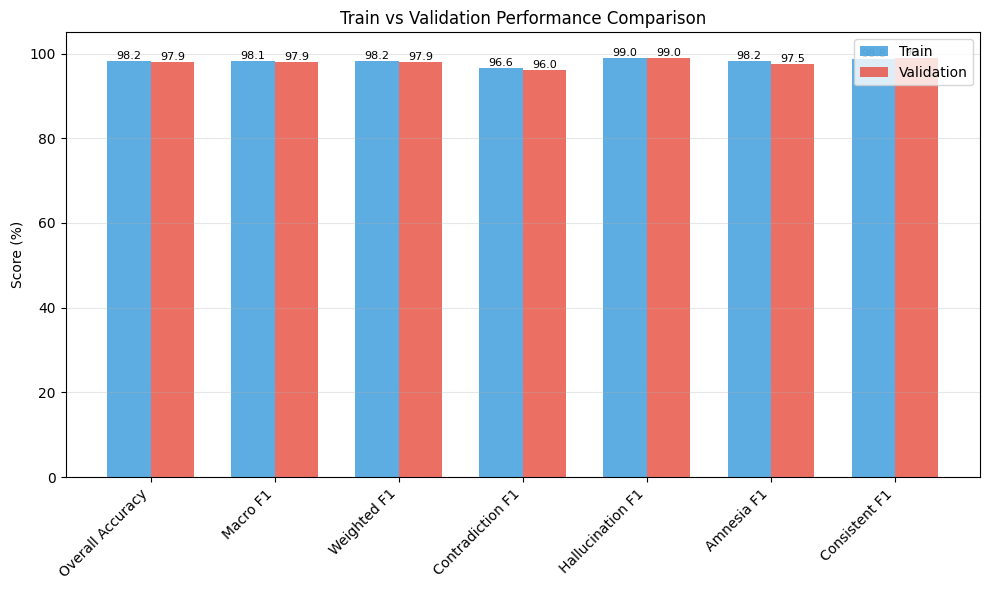

In [62]:
print("="*80)
print("OVERFITTING ANALYSIS - Comparing Train vs Validation Performance")
print("="*80)

# Evaluate on training set (sample for speed)
train_sample_size = min(5000, len(train_dataset))
train_sample_indices = random.sample(range(len(train_dataset)), train_sample_size)
train_sample_dataset = torch.utils.data.Subset(train_dataset, train_sample_indices)

print(f"\nEvaluating on {train_sample_size:,} training samples...")
train_eval_results = trainer.evaluate(train_sample_dataset)

print(f"\nEvaluating on full validation set ({len(val_dataset):,} samples)...")
val_eval_results = trainer.evaluate(val_dataset)

# Compare metrics
print("\n" + "="*80)
print("TRAIN vs VALIDATION COMPARISON:")
print("="*80)

metrics_to_compare = [
    ('accuracy', 'Overall Accuracy'),
    ('macro_f1', 'Macro F1'),
    ('weighted_f1', 'Weighted F1'),
    ('contradiction_f1', 'Contradiction F1'),
    ('hallucination_f1', 'Hallucination F1'),
    ('amnesia_f1', 'Amnesia F1'),
    ('consistent_f1', 'Consistent F1'),
]

print(f"\n{'Metric':<25} {'Train':<15} {'Validation':<15} {'Difference':<15}")
print("-"*80)

overfitting_indicators = []

for metric_key, metric_name in metrics_to_compare:
    train_metric = train_eval_results.get(f'eval_{metric_key}', 0) * 100
    val_metric = val_eval_results.get(f'eval_{metric_key}', 0) * 100
    difference = train_metric - val_metric
    
    # Flag if train is >5% better than val
    flag = "⚠️ OVERFIT" if difference > 5.0 else ""
    
    if difference > 5.0:
        overfitting_indicators.append((metric_name, difference))
    
    print(f"{metric_name:<25} {train_metric:>6.2f}%       {val_metric:>6.2f}%       {difference:+6.2f}%  {flag}")

print("="*80)

# Diagnosis
if overfitting_indicators:
    print("\n⚠️  OVERFITTING DETECTED!")
    print("\nThe model performs significantly better on training data than validation data.")
    print("Metrics with >5% gap:")
    for metric_name, diff in overfitting_indicators:
        print(f"  • {metric_name}: {diff:+.2f}% gap")
    
    print("\nPossible causes:")
    print("  1. Model is memorizing training examples rather than learning patterns")
    print("  2. Training data has very predictable/simple patterns")
    print("  3. Corruption functions create easily detectable artifacts")
    print("  4. Not enough data diversity")
    
    print("\nRecommended solutions:")
    print("  ✓ Add more diverse corruption strategies")
    print("  ✓ Increase corruption randomness/subtlety")
    print("  ✓ Add data augmentation (paraphrasing, synonym replacement)")
    print("  ✓ Reduce model capacity (already using deberta-v3-small)")
    print("  ✓ Increase dropout rate")
    print("  ✓ Add more regularization (higher weight_decay)")
    print("  ✓ Early stopping (already enabled)")
else:
    print("\n✓ No significant overfitting detected!")
    print("Train and validation performance are similar.")

print("\n" + "="*80)

# Visualize train vs val metrics
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

metrics_names = [name for _, name in metrics_to_compare]
train_scores = [train_eval_results.get(f'eval_{key}', 0) * 100 for key, _ in metrics_to_compare]
val_scores = [val_eval_results.get(f'eval_{key}', 0) * 100 for key, _ in metrics_to_compare]

x = np.arange(len(metrics_names))
width = 0.35

bars1 = ax.bar(x - width/2, train_scores, width, label='Train', color='#3498db', alpha=0.8)
bars2 = ax.bar(x + width/2, val_scores, width, label='Validation', color='#e74c3c', alpha=0.8)

ax.set_ylabel('Score (%)')
ax.set_title('Train vs Validation Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(metrics_names, rotation=45, ha='right')
ax.legend()
ax.set_ylim([0, 105])
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}',
                ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()



PREDICTION CONFIDENCE ANALYSIS

Validation Set Confidence Statistics:
  Mean confidence: 92.69%
  Median confidence: 94.37%
  Std dev: 9.10%

Confidence distribution:
  >99% confident: 0.0%
  >95% confident: 0.0%
  >90% confident: 96.9%
  <70% confident: 3.1%

--------------------------------------------------------------------------------
✓ Confidence levels look reasonable
   Only 0.0% of predictions have >99% confidence

Incorrect predictions analysis:
  Mean confidence on WRONG predictions: 47.02%
  Mean confidence on CORRECT predictions: 93.65%


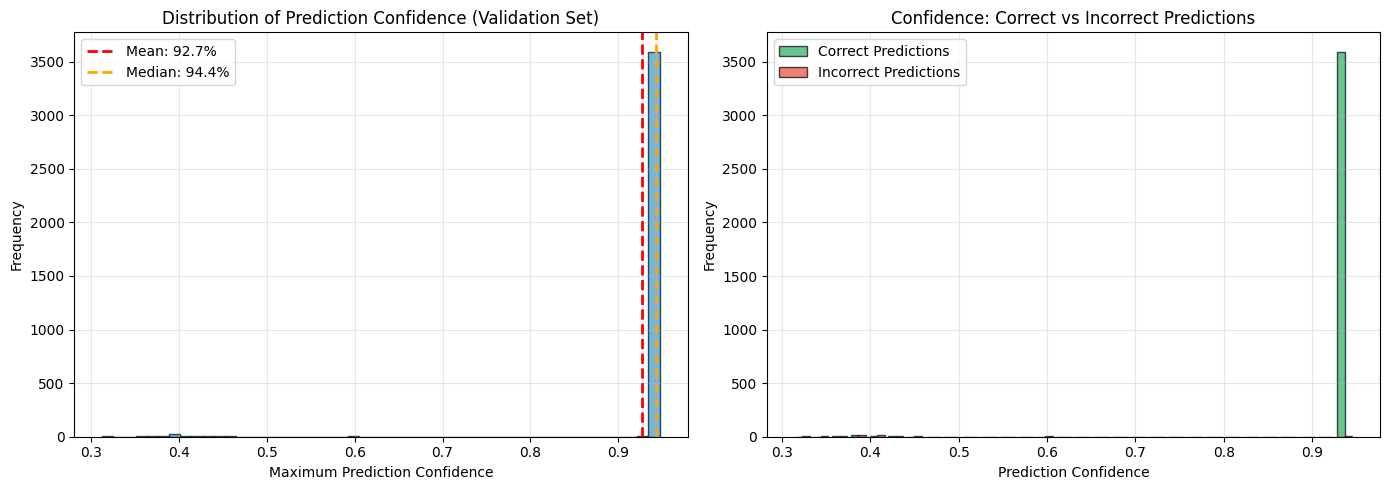

In [63]:
# Analyze prediction confidence - overfitted models are often overconfident
print("\n" + "="*80)
print("PREDICTION CONFIDENCE ANALYSIS")
print("="*80)

# Get probabilities from validation set
val_predictions_output = trainer.predict(val_dataset)
val_pred_probs = torch.softmax(torch.tensor(val_predictions_output.predictions), dim=1).numpy()

# Get max confidence for each prediction
max_confidences = np.max(val_pred_probs, axis=1)

# Analyze confidence distribution
print(f"\nValidation Set Confidence Statistics:")
print(f"  Mean confidence: {np.mean(max_confidences)*100:.2f}%")
print(f"  Median confidence: {np.median(max_confidences)*100:.2f}%")
print(f"  Std dev: {np.std(max_confidences)*100:.2f}%")
print(f"\nConfidence distribution:")
print(f"  >99% confident: {np.sum(max_confidences > 0.99) / len(max_confidences) * 100:.1f}%")
print(f"  >95% confident: {np.sum(max_confidences > 0.95) / len(max_confidences) * 100:.1f}%")
print(f"  >90% confident: {np.sum(max_confidences > 0.90) / len(max_confidences) * 100:.1f}%")
print(f"  <70% confident: {np.sum(max_confidences < 0.70) / len(max_confidences) * 100:.1f}%")

# Overfitting indicator: too many predictions with >99% confidence
overconfident_ratio = np.sum(max_confidences > 0.99) / len(max_confidences)

print("\n" + "-"*80)
if overconfident_ratio > 0.5:
    print("⚠️  MODEL IS OVERCONFIDENT!")
    print(f"   {overconfident_ratio*100:.1f}% of predictions have >99% confidence")
    print("\nThis is a strong indicator of overfitting:")
    print("  • Model is too certain about its predictions")
    print("  • Likely memorizing patterns rather than learning generalizable features")
    print("  • May struggle with real-world examples that differ from training data")
elif overconfident_ratio > 0.3:
    print("⚠️  MODEL IS MODERATELY OVERCONFIDENT")
    print(f"   {overconfident_ratio*100:.1f}% of predictions have >99% confidence")
    print("   This suggests some overfitting, but not severe")
else:
    print("✓ Confidence levels look reasonable")
    print(f"   Only {overconfident_ratio*100:.1f}% of predictions have >99% confidence")

print("="*80)

# Visualize confidence distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of max confidence
axes[0].hist(max_confidences, bins=50, edgecolor='black', alpha=0.7, color='#3498db')
axes[0].axvline(np.mean(max_confidences), color='red', linestyle='--', 
                label=f'Mean: {np.mean(max_confidences)*100:.1f}%', linewidth=2)
axes[0].axvline(np.median(max_confidences), color='orange', linestyle='--', 
                label=f'Median: {np.median(max_confidences)*100:.1f}%', linewidth=2)
axes[0].set_xlabel('Maximum Prediction Confidence')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Prediction Confidence (Validation Set)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Correct vs incorrect confidence
val_predictions = np.argmax(val_pred_probs, axis=1)
val_labels = val_predictions_output.label_ids
correct_mask = val_predictions == val_labels

correct_confidences = max_confidences[correct_mask]
incorrect_confidences = max_confidences[~correct_mask]

axes[1].hist([correct_confidences, incorrect_confidences], bins=30, 
             label=['Correct Predictions', 'Incorrect Predictions'],
             color=['#27ae60', '#e74c3c'], alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Prediction Confidence')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Confidence: Correct vs Incorrect Predictions')
axes[1].legend()
axes[1].grid(alpha=0.3)

if len(incorrect_confidences) > 0:
    print(f"\nIncorrect predictions analysis:")
    print(f"  Mean confidence on WRONG predictions: {np.mean(incorrect_confidences)*100:.2f}%")
    print(f"  Mean confidence on CORRECT predictions: {np.mean(correct_confidences)*100:.2f}%")
    
    if np.mean(incorrect_confidences) > 0.8:
        print("\n  ⚠️  Model is confident even when wrong - strong overfitting indicator!")

plt.tight_layout()
plt.show()


In [65]:
print("="*80)
print("ADDITIONAL ANTI-OVERFITTING STRATEGIES")
print("="*80)

print("\nIf overfitting persists after the improvements made above, try these:")

print("\n1. DATA AUGMENTATION")
print("   ✓ Back-translation: Translate to another language and back")
print("   ✓ Synonym replacement: Replace words with synonyms")
print("   ✓ Random insertion/deletion of words")
print("   ✓ Paraphrasing with a language model")
print("   Code example:")
print("     # pip install nlpaug")
print("     # import nlpaug.augmenter.word as naw")
print("     # aug = naw.SynonymAug(aug_src='wordnet')")
print("     # augmented_text = aug.augment(text)")

print("\n2. DROPOUT REGULARIZATION")
print("   ✓ Increase hidden dropout (currently model default ~0.1)")
print("   ✓ Add dropout to attention layers")
print("   Code example:")
print("     # from transformers import AutoConfig")
print("     # config = AutoConfig.from_pretrained(MODEL_NAME)")
print("     # config.hidden_dropout_prob = 0.2  # Increase from default")
print("     # config.attention_probs_dropout_prob = 0.2")
print("     # model = AutoModelForSequenceClassification.from_pretrained(")
print("     #     MODEL_NAME, config=config, num_labels=NUM_LABELS)")

print("\n3. REDUCE MODEL CAPACITY")
print("   ✓ Freeze some layers (train only top layers)")
print("   ✓ Use an even smaller model (distilroberta-base)")
print("   Code example:")
print("     # Freeze first 6 layers")
print("     # for layer in model.deberta.encoder.layer[:6]:")
print("     #     for param in layer.parameters():")
print("     #         param.requires_grad = False")

print("\n4. MIXUP TRAINING")
print("   ✓ Mix examples from different classes during training")
print("   ✓ Creates 'in-between' examples to prevent memorization")
print("   Note: Requires custom training loop")

print("\n5. ADVERSARIAL TRAINING")
print("   ✓ Add small perturbations to embeddings during training")
print("   ✓ Forces model to be robust to small changes")
print("   Note: Computationally expensive")

print("\n6. ENSEMBLE METHODS")
print("   ✓ Train multiple models with different random seeds")
print("   ✓ Average their predictions")
print("   ✓ Reduces overfitting through model averaging")

print("\n7. MORE TRAINING DATA")
print("   ✓ Increase from 40K to 100K+ examples")
print("   ✓ Use more CRD3 episodes")
print("   ✓ Combine multiple D&D datasets")

print("\n8. CURRICULUM LEARNING")
print("   ✓ Start with easy examples (obvious corruptions)")
print("   ✓ Gradually increase difficulty (subtle corruptions)")
print("   ✓ Helps model learn generalizable patterns")

print("\n" + "="*80)
print("RECOMMENDED NEXT STEPS:")
print("="*80)
print("\n1. Re-train with improved corruption functions (most important!)")
print("2. Monitor train vs val metrics during training")
print("3. If still overfitting, add dropout regularization (#2)")
print("4. If still overfitting, try data augmentation (#1)")
print("5. Consider freezing layers (#3) for faster experiments")
print("\n" + "="*80)


ADDITIONAL ANTI-OVERFITTING STRATEGIES

If overfitting persists after the improvements made above, try these:

1. DATA AUGMENTATION
   ✓ Back-translation: Translate to another language and back
   ✓ Synonym replacement: Replace words with synonyms
   ✓ Random insertion/deletion of words
   ✓ Paraphrasing with a language model
   Code example:
     # pip install nlpaug
     # import nlpaug.augmenter.word as naw
     # aug = naw.SynonymAug(aug_src='wordnet')
     # augmented_text = aug.augment(text)

2. DROPOUT REGULARIZATION
   ✓ Increase hidden dropout (currently model default ~0.1)
   ✓ Add dropout to attention layers
   Code example:
     # from transformers import AutoConfig
     # config = AutoConfig.from_pretrained(MODEL_NAME)
     # config.hidden_dropout_prob = 0.2  # Increase from default
     # config.attention_probs_dropout_prob = 0.2
     # model = AutoModelForSequenceClassification.from_pretrained(
     #     MODEL_NAME, config=config, num_labels=NUM_LABELS)

3. REDUCE MODEL

## 10. Comprehensive Evaluation on Test Set

In [66]:
# Evaluate on test set
print("Evaluating on test set...")
test_results = trainer.evaluate(test_dataset)

print("\n" + "="*80)
print("TEST SET RESULTS:")
print("="*80)
print(f"Overall Accuracy: {test_results['eval_accuracy']*100:.2f}%")
print(f"Macro F1: {test_results['eval_macro_f1']*100:.2f}%")
print(f"Weighted F1: {test_results['eval_weighted_f1']*100:.2f}%")

print("\nPer-Class Metrics:")
print("-"*80)
print(f"{'Class':<15} {'Precision':<12} {'Recall':<12} {'F1-Score':<12}")
print("-"*80)

class_names = ['contradiction', 'hallucination', 'amnesia', 'consistent']
for name in class_names:
    precision = test_results.get(f'eval_{name}_precision', 0) * 100
    recall = test_results.get(f'eval_{name}_recall', 0) * 100
    f1 = test_results.get(f'eval_{name}_f1', 0) * 100
    print(f"{name.capitalize():<15} {precision:>6.2f}%      {recall:>6.2f}%      {f1:>6.2f}%")

print("="*80)

Evaluating on test set...



TEST SET RESULTS:
Overall Accuracy: 98.39%
Macro F1: 98.37%
Weighted F1: 98.40%

Per-Class Metrics:
--------------------------------------------------------------------------------
Class           Precision    Recall       F1-Score    
--------------------------------------------------------------------------------
Contradiction    94.59%       99.54%       97.01%
Hallucination   100.00%       98.86%       99.42%
Amnesia          99.22%       97.07%       98.13%
Consistent       99.68%       98.13%       98.90%


In [67]:
# Get predictions for detailed analysis
predictions_output = trainer.predict(test_dataset)
predictions = np.argmax(predictions_output.predictions, axis=1)
true_labels = predictions_output.label_ids

# Confusion matrix
cm = confusion_matrix(true_labels, predictions)

# Classification report
print("\nDetailed Classification Report:")
print(classification_report(
    true_labels, 
    predictions, 
    target_names=['Contradiction', 'Hallucination', 'Amnesia', 'Consistent'],
    digits=4
))


Detailed Classification Report:
               precision    recall  f1-score   support

Contradiction     0.9459    0.9954    0.9701       879
Hallucination     1.0000    0.9886    0.9942       961
      Amnesia     0.9922    0.9707    0.9813       920
   Consistent     0.9968    0.9813    0.9890       961

     accuracy                         0.9839      3721
    macro avg     0.9837    0.9840    0.9837      3721
 weighted avg     0.9845    0.9839    0.9840      3721



## 11. Visualize Training Progress and Results

<Figure size 1600x500 with 0 Axes>

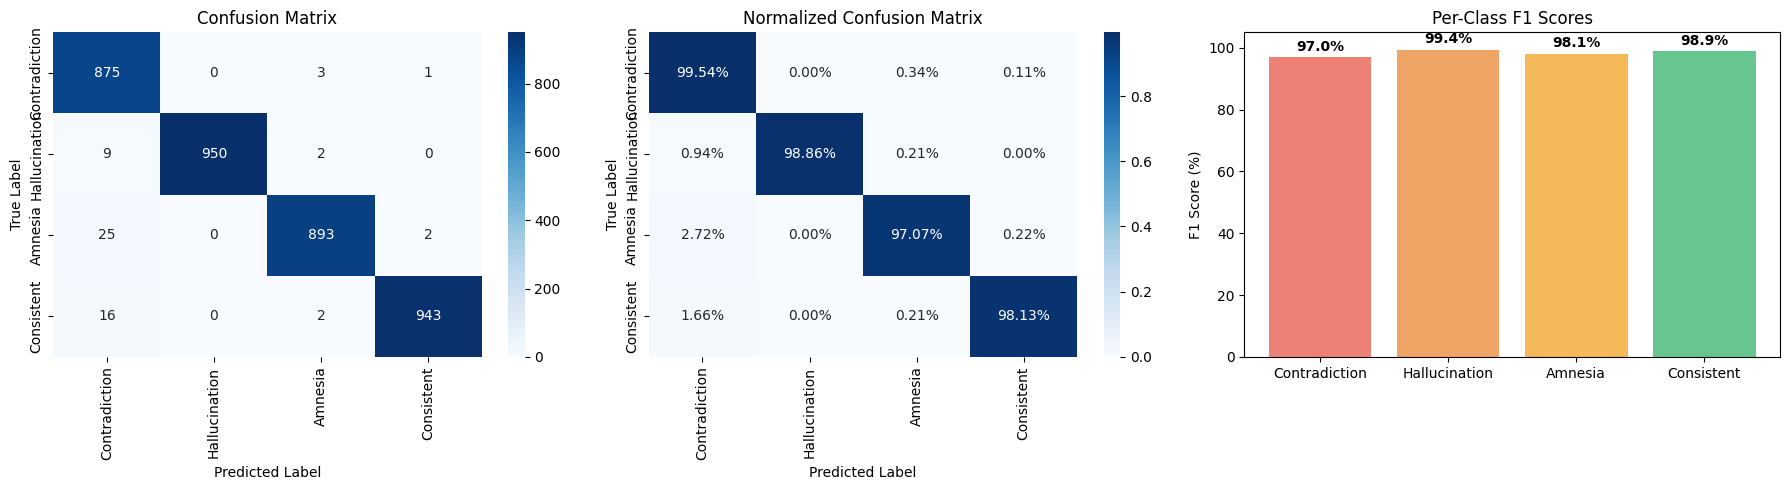

In [68]:
# Visualize confusion matrix
fig, axes = plt.figure(figsize=(16, 5)), plt.subplots(1, 3, figsize=(18, 5))

# Confusion Matrix
plt.subplot(1, 3, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Contradiction', 'Hallucination', 'Amnesia', 'Consistent'],
            yticklabels=['Contradiction', 'Hallucination', 'Amnesia', 'Consistent'])
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

# Normalize confusion matrix
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.subplot(1, 3, 2)
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=['Contradiction', 'Hallucination', 'Amnesia', 'Consistent'],
            yticklabels=['Contradiction', 'Hallucination', 'Amnesia', 'Consistent'])
plt.title('Normalized Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

# Per-class F1 scores
plt.subplot(1, 3, 3)
f1_scores = [
    test_results['eval_contradiction_f1'] * 100,
    test_results['eval_hallucination_f1'] * 100,
    test_results['eval_amnesia_f1'] * 100,
    test_results['eval_consistent_f1'] * 100
]
colors = ['#e74c3c', '#e67e22', '#f39c12', '#27ae60']
bars = plt.bar(['Contradiction', 'Hallucination', 'Amnesia', 'Consistent'], 
               f1_scores, color=colors, alpha=0.7)
plt.ylabel('F1 Score (%)')
plt.title('Per-Class F1 Scores')
plt.ylim([0, 105])
for bar, score in zip(bars, f1_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{score:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

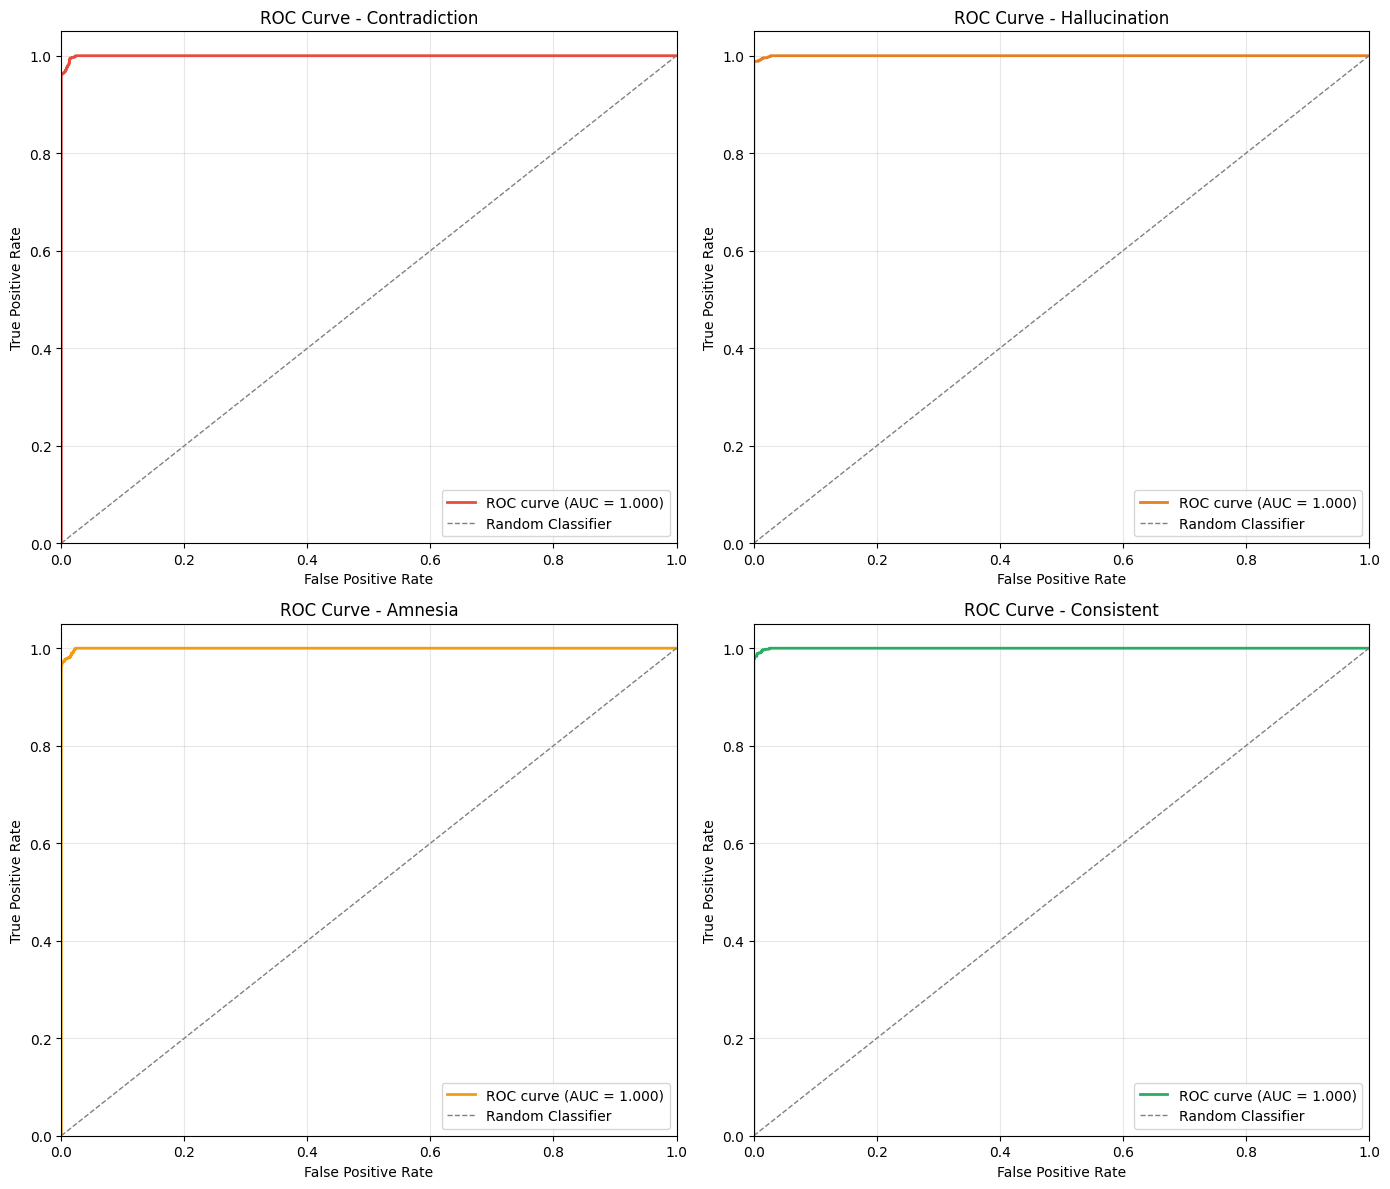


AUC Scores:
----------------------------------------
Contradiction   AUC = 0.9996
Hallucination   AUC = 0.9998
Amnesia         AUC = 0.9996
Consistent      AUC = 0.9998


In [69]:
# ROC Curves and AUC for each class
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Get prediction probabilities
pred_probs = torch.softmax(torch.tensor(predictions_output.predictions), dim=1).numpy()

# Binarize labels for multiclass ROC
y_test_bin = label_binarize(true_labels, classes=[0, 1, 2, 3])

class_names_roc = ['Contradiction', 'Hallucination', 'Amnesia', 'Consistent']
colors_roc = ['#e74c3c', '#e67e22', '#f39c12', '#27ae60']

for idx, (ax, class_name, color) in enumerate(zip(axes.flatten(), class_names_roc, colors_roc)):
    # Compute ROC curve
    fpr, tpr, _ = roc_curve(y_test_bin[:, idx], pred_probs[:, idx])
    roc_auc = auc(fpr, tpr)
    
    # Plot ROC curve
    ax.plot(fpr, tpr, color=color, lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
    ax.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random Classifier')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'ROC Curve - {class_name}')
    ax.legend(loc="lower right")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Print AUC scores
print("\nAUC Scores:")
print("-"*40)
for idx, class_name in enumerate(class_names_roc):
    fpr, tpr, _ = roc_curve(y_test_bin[:, idx], pred_probs[:, idx])
    roc_auc = auc(fpr, tpr)
    print(f"{class_name:<15} AUC = {roc_auc:.4f}")

## 12. Test Model on Hand-Crafted Examples

In [70]:
def test_example(text, expected_label=None):
    """Test model on a single example"""
    # Tokenize
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512, padding=True)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    # Get prediction
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        probs = torch.softmax(logits, dim=1)[0]
        predicted_class = torch.argmax(logits, dim=1).item()
    
    # Print results
    print(f"\nText: {text[:150]}...")
    print(f"\nPredicted: {label_names[predicted_class]}")
    if expected_label is not None:
        # Fix: compare lowercase versions for proper matching
        is_correct = label_names[predicted_class].lower() == expected_label.lower()
        print(f"Expected: {expected_label}")
        print(f"✓ Correct!" if is_correct else "✗ Wrong")
    
    print(f"\nProbabilities:")
    for i, prob in enumerate(probs):
        print(f"  {label_names[i]}: {prob.item()*100:.2f}%")
    print("-"*80)

print("="*80)
print("Testing on Hand-Crafted Examples:")
print("="*80)

# Test Contradiction
test_example(
    "You unlock the door with the rusty key [SEP] The door swings open, revealing a dark corridor. [RESPONSE] The locked door blocks your path.",
    expected_label="contradiction"
)

# Test Hallucination
test_example(
    "You enter the quiet tavern [SEP] The room is nearly empty. [RESPONSE] The tavern explodes with activity: ten merchants, eight guards, five bards, and seven scholars fill the room.",
    expected_label="hallucination"
)

# Test Amnesia
test_example(
    "The innkeeper says 'Welcome! I am Gregor.' [SEP] You chat with the innkeeper. [RESPONSE] The innkeeper smiles warmly, though you can't recall his name.",
    expected_label="amnesia"
)

# Test Consistent
test_example(
    "You carefully pick the lock on the chest [SEP] The chest opens with a satisfying click. [RESPONSE] Inside the chest, you find a golden amulet and three healing potions.",
    expected_label="consistent"
)


Testing on Hand-Crafted Examples:

Text: You unlock the door with the rusty key [SEP] The door swings open, revealing a dark corridor. [RESPONSE] The locked door blocks your path....

Predicted: Contradiction
Expected: contradiction
✓ Correct!

Probabilities:
  Contradiction: 87.60%
  Hallucination: 3.10%
  Amnesia: 2.91%
  Consistent: 6.40%
--------------------------------------------------------------------------------

Text: You enter the quiet tavern [SEP] The room is nearly empty. [RESPONSE] The tavern explodes with activity: ten merchants, eight guards, five bards, and ...

Predicted: Hallucination
Expected: hallucination
✓ Correct!

Probabilities:
  Contradiction: 2.02%
  Hallucination: 94.07%
  Amnesia: 1.92%
  Consistent: 1.99%
--------------------------------------------------------------------------------

Text: The innkeeper says 'Welcome! I am Gregor.' [SEP] You chat with the innkeeper. [RESPONSE] The innkeeper smiles warmly, though you can't recall his name...

Predicted:

## 13. Save Trained Model for Integration

In [72]:
# Save the trained model and tokenizer
SAVE_DIR = "/kaggle/working/world_consistency_critic_final2"

print(f"Saving model to {SAVE_DIR}...")
model.save_pretrained(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)

# Save training configuration
config = {
    'model_name': MODEL_NAME,
    'num_labels': NUM_LABELS,
    'label_mapping': {
        0: 'contradiction',
        1: 'hallucination',
        2: 'amnesia',
        3: 'consistent'
    },
    'score_mapping': {
        'contradiction': 0.0,
        'hallucination': 0.3,
        'amnesia': 0.5,
        'consistent': 1.0
    },
    'test_accuracy': float(test_results['eval_accuracy']),
    'test_macro_f1': float(test_results['eval_macro_f1']),
    'training_examples': len(train_data),
    'val_examples': len(val_data),
    'test_examples': len(test_data),
}

with open(f"{SAVE_DIR}/training_config.json", 'w') as f:
    json.dump(config, f, indent=2)

print(f"✓ Model saved to {SAVE_DIR}")
print(f"✓ Training configuration saved")

# Print summary
print("\n" + "="*80)
print("MODEL SUMMARY:")
print("="*80)
print(f"Model: {MODEL_NAME}")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"\nTest Performance:")
print(f"  Accuracy: {config['test_accuracy']*100:.2f}%")
print(f"  Macro F1: {config['test_macro_f1']*100:.2f}%")
print(f"\nLabel Mapping:")
for label_id, label_name in config['label_mapping'].items():
    score = config['score_mapping'][label_name]
    print(f"  {label_id}: {label_name} → score {score}")
print(f"\nModel ready for integration into Director LLM Critics!")
print("="*80)

Saving model to /kaggle/working/world_consistency_critic_final2...
✓ Model saved to /kaggle/working/world_consistency_critic_final2
✓ Training configuration saved

MODEL SUMMARY:
Model: microsoft/deberta-v3-small
Parameters: 141,897,988

Test Performance:
  Accuracy: 98.39%
  Macro F1: 98.37%

Label Mapping:
  0: contradiction → score 0.0
  1: hallucination → score 0.3
  2: amnesia → score 0.5
  3: consistent → score 1.0

Model ready for integration into Director LLM Critics!
